*Разведочный анализ данных (EDA)*

**План:**

Загрузка данных

**Часть 1. Предварительный анализ данных (EDA)**

1.1 Общая статистика ДТП
- Количество ДТП по годам (динамика аварийности)
- Количество ДТП по месяцам (сезонность)
- Распределение по городам (Петрозаводск, Тамбов, Великий Новгород)
- Соотношение погибших и раненых
- Самые частые виды ДТП

1.2 Временные паттерны ДТП
- Распределение по часам суток (когда больше всего ДТП?)
- Распределение по дням недели
- Сезонные колебания по месяцам
- Анализ тяжести ДТП в разных временных разрезах

1.3 Анализ участников ДТП
- Соотношение водителей/пассажиров/пешеходов по городам
- Пол и возраст участников
- Анализ опыта водителей в разных типах ДТП
- Тяжесть последствий для разных ролей (водитель vs пешеход)
- Гендерный анализ погибших и раненых

1.4 Анализ транспортных средств
- Типы ТС — участников ДТП (топ-10)
- Связь типа ТС с видом ДТП
- Техническое состояние ТС
- Марки автомобилей (топ-10)
- Цвета автомобилей и их связь с тяжестью ДТП (корреляционный анализ)


**Часть 2. Анализ влияния погодных условий на ДТП**

2.2 Анализ погодных условий в момент ДТП
- Распределение ДТП по типам погоды
- Влияние погоды на тяжесть ДТП
- Анализ сочетаний погодных условий

2.3 Анализ температуры
- Распределение ДТП по температурным режимам
- Связь температуры с тяжестью ДТП

2.4 Анализ осадков
- Распределение ДТП по типам осадков
- Влияние осадков на тяжесть ДТП

2.5 Анализ дорожных условий
- Состояние покрытия (топ-8)
- Условия освещения

2.6 Недостатки дороги
- Топ-10 недостатков
- Статистика по недостаткам

2.7 Городская специфика
- Сравнение трех городов по погодным условиям при ДТП

2.8 Общая статистика

**Часть 3. Статистическая проверка гипотез**

3.1. Гипотеза 1: Сравнение доли смертельных ДТП

3.2. Гипотеза 2: Сравнение доли ДТП с осадками

3.3. Гипотеза 3: Сравнение смертности при дожде

3.4. Гипотеза 4: Сравнение доли ДТП со сложными условиями покрытия

3.5. Гипотеза 5: Сравнение доли ДТП в темное время суток

3.6. Общие выводы по результатам проверки гипотез



*Загрузка данных*

In [141]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import numpy as np 
from scipy.stats import pearsonr, spearmanr, chi2_contingency, mannwhitneyu

In [2]:
%matplotlib inline

In [3]:
# настройка вывода
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)  
pd.set_option('display.width', None)     
pd.set_option('display.max_colwidth', None) 

In [4]:
load_dotenv()

True

In [5]:
DATABASE_URL = f"postgresql+psycopg2://{os.getenv('SUPABASE_DB_USER')}:{os.getenv('SUPABASE_DB_PASSWORD')}@{os.getenv('SUPABASE_DB_HOST')}:{os.getenv('SUPABASE_DB_PORT')}/{os.getenv('SUPABASE_DB_NAME')}?sslmode=require"

In [6]:
engine = create_engine(DATABASE_URL)

In [9]:
dtp_main = pd.read_sql_query("SELECT * FROM dtp_main", engine)
dtp_main.head()

,id,kart_id,city_id,row_num,date,time,district,dtp_type,fatalities,injured,vehicles_count,participants_count,emtp_number,raw_data,created_at,updated_at
0,14362,161368315,763e286c-fc7b-4d1b-b2e1-463fced954be,1,2015-01-31,15:50:00,г.Петрозаводск,Наезд на пешехода,0,1,1,2,NaN,None,2026-02-18 21:01:53.837920+00:00,2026-02-18 21:01:53.837920+00:00
1,14363,161361156,763e286c-fc7b-4d1b-b2e1-463fced954be,2,2015-01-30,20:00:00,г.Петрозаводск,Наезд на пешехода,0,1,1,2,NaN,None,2026-02-18 21:01:53.837920+00:00,2026-02-18 21:01:53.837920+00:00
2,14364,161354221,763e286c-fc7b-4d1b-b2e1-463fced954be,3,2015-01-30,18:00:00,г.Петрозаводск,Столкновение,0,1,2,2,NaN,None,2026-02-18 21:01:53.837920+00:00,2026-02-18 21:01:53.837920+00:00
3,14365,161356960,763e286c-fc7b-4d1b-b2e1-463fced954be,4,2015-01-30,23:25:00,г.Петрозаводск,Наезд на пешехода,0,1,1,2,NaN,None,2026-02-18 21:01:53.837920+00:00,2026-02-18 21:01:53.837920+00:00
4,14366,161014447,763e286c-fc7b-4d1b-b2e1-463fced954be,5,2015-01-29,17:50:00,г.Петрозаводск,Наезд на пешехода,0,1,1,2,NaN,None,2026-02-18 21:01:53.837920+00:00,2026-02-18 21:01:53.837920+00:00


In [10]:
dtp_main['district'].value_counts()

district
Тамбов            5256
г Новгород        3751
г.Петрозаводск    2685
Name: count, dtype: int64

In [11]:
# словарь для соотнесения city_name из cities с district в dtp_main
city_name_mapping = {
    'г.Петрозаводск': 'Петрозаводск',
    'г Новгород': 'Великий Новгород',
    'Тамбов': 'Тамбов'
}
dtp_main['district'] = dtp_main['district'].map(city_name_mapping)

In [12]:
dtp_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 11692 entries, 0 to 11691
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   id                  11692 non-null  int64              
 1   kart_id             11692 non-null  int64              
 2   city_id             11692 non-null  object             
 3   row_num             11692 non-null  int64              
 4   date                11692 non-null  object             
 5   time                11692 non-null  object             
 6   district            11692 non-null  str                
 7   dtp_type            11692 non-null  str                
 8   fatalities          11692 non-null  int64              
 9   injured             11692 non-null  int64              
 10  vehicles_count      11692 non-null  int64              
 11  participants_count  11692 non-null  int64              
 12  emtp_number         5515 non-null   str    

In [13]:
dtp_participants = pd.read_sql_query("SELECT * FROM dtp_participants", engine)
dtp_participants.head()

,id,kart_id,vehicle_id,participant_number,role,injury_severity,gender,driving_experience,alcohol,seatbelt_used,hid_from_scene,seat_group,injured_card_id,violations,additional_violations,is_from_uch_info,created_at,updated_at
0,7341,161368315,None,1,Водитель,Не пострадал,Мужской,3.0,NaN,Да,Нет (не скрывался),NaN,None,[Нет нарушений],[Нет нарушений],False,2026-02-18 21:02:45.445151+00:00,2026-02-18 21:02:45.445151+00:00
1,7342,161368315,None,2,Пешеход,"Раненый, находящийся (находившийся) на стационарном лечении",Женский,NaN,NaN,NaN,Нет (не скрывался),NaN,None,[Переход проезжей части в запрещённом месте (оборудованном пешеходными ограждениями)],[Нет нарушений],True,2026-02-18 21:02:45.445151+00:00,2026-02-18 21:02:45.445151+00:00
2,7343,161361156,None,1,Водитель,Не пострадал,Мужской,3.0,NaN,Да,"Скрылся, впоследствии разыскан (установлен)",NaN,None,[Нарушение правил проезда пешеходного перехода],[Оставление места ДТП],False,2026-02-18 21:02:45.445151+00:00,2026-02-18 21:02:45.445151+00:00
3,7344,161361156,None,2,Пешеход,"Раненый, находящийся (находившийся) на амбулаторном лечении, либо которому по характеру полученных травм обозначена необходимость амбулаторного лечения (вне зависимости от его фактического прохождения)",Женский,NaN,NaN,NaN,Нет (не скрывался),NaN,None,[Нет нарушений],[Нет нарушений],True,2026-02-18 21:02:45.445151+00:00,2026-02-18 21:02:45.445151+00:00
4,7345,161354221,None,2,Водитель,Не пострадал,Мужской,30.0,NaN,Да,Нет (не скрывался),NaN,None,[Нет нарушений],[Нет нарушений],False,2026-02-18 21:02:45.445151+00:00,2026-02-18 21:02:45.445151+00:00


In [14]:
dtp_participants.info()

<class 'pandas.DataFrame'>
RangeIndex: 29984 entries, 0 to 29983
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     29984 non-null  int64              
 1   kart_id                29984 non-null  int64              
 2   vehicle_id             0 non-null      object             
 3   participant_number     29984 non-null  str                
 4   role                   29984 non-null  str                
 5   injury_severity        29984 non-null  str                
 6   gender                 29984 non-null  str                
 7   driving_experience     18734 non-null  float64            
 8   alcohol                7982 non-null   str                
 9   seatbelt_used          26061 non-null  str                
 10  hid_from_scene         29984 non-null  str                
 11  seat_group             365 non-null    str                
 12  i

In [15]:
dtp_vehicles = pd.read_sql_query("SELECT * FROM dtp_vehicles", engine)
dtp_vehicles.head()

,id,kart_id,vehicle_number_in_accident,vehicle_status,vehicle_type,make,model,color,steering,year,engine_capacity,technical_condition,ownership_form,owner_type,created_at,updated_at
0,23539,161368315,1,Нет,"В-класс (малый) до 3,9 м",NISSAN,Teana,Серый,Передний,2008.0,"Передний правый бок (передняя дверь пассажира, в случае ТС с правым расположением руля передняя дверь водителя)",Технические неисправности отсутствуют,Частная собственность,NaN,2026-02-18 21:02:41.835011+00:00,2026-02-18 21:02:41.835011+00:00
1,23540,161361156,1,до 1 сут.,"С-класс (малый средний, компактный) до 4,3 м",VOLKSWAGEN,Vento,Иные цвета,Передний,1992.0,Передний правый угол | Передний левый угол,Технические неисправности отсутствуют,Частная собственность,NaN,2026-02-18 21:02:41.835011+00:00,2026-02-18 21:02:41.835011+00:00
2,23541,161354221,2,Нет,Седельные тягачи,МАЗ-МАН,630368,Белый,Передний,2011.0,Передний правый угол | Передний левый угол,Технические неисправности отсутствуют,Частная собственность,NaN,2026-02-18 21:02:41.835011+00:00,2026-02-18 21:02:41.835011+00:00
3,23542,161354221,1,Нет,"В-класс (малый) до 3,9 м",ВАЗ,Жигули ВАЗ-2106 модификации,Иные цвета,Задний,2004.0,Передний правый угол | Передний левый угол,Технические неисправности отсутствуют,Частная собственность,NaN,2026-02-18 21:02:41.835011+00:00,2026-02-18 21:02:41.835011+00:00
4,23543,161356960,1,Нет,"С-класс (малый средний, компактный) до 4,3 м",VOLKSWAGEN,Polo,Иные цвета,Передний,2014.0,Передний левый угол,Технические неисправности отсутствуют,Частная собственность,NaN,2026-02-18 21:02:41.835011+00:00,2026-02-18 21:02:41.835011+00:00


In [17]:
dtp_vehicles.info()

<class 'pandas.DataFrame'>
RangeIndex: 19767 entries, 0 to 19766
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   id                          19767 non-null  int64              
 1   kart_id                     19767 non-null  int64              
 2   vehicle_number_in_accident  19767 non-null  str                
 3   vehicle_status              19767 non-null  str                
 4   vehicle_type                19767 non-null  str                
 5   make                        18687 non-null  str                
 6   model                       18687 non-null  str                
 7   color                       19278 non-null  str                
 8   steering                    18868 non-null  str                
 9   year                        18715 non-null  float64            
 10  engine_capacity             4971 non-null   str                
 11  

In [18]:
dtp_road_conditions = pd.read_sql_query("SELECT * FROM dtp_road_conditions", engine)
dtp_road_conditions.head()

,id,kart_id,settlement,street,house,road,kilometer,meter,road_category,road_code,road_value,road_surface,light_conditions,traffic_change,accident_code,latitude,longitude,road_deficiencies,traffic_scheme,factors,weather_conditions,traffic_objects,created_at,updated_at
0,14057,161368315,г Петрозаводск,ул Лыжная,2,NaN,0.0,0.0,None,None,None,Обработанное противогололедными материалами,Светлое время суток,None,None,61.769444,34.390556,"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]",[Перегон (нет объектов на месте ДТП)],None,[Пасмурно],[АЗС],2026-02-18 21:02:36.491689+00:00,2026-02-18 21:02:36.491689+00:00
1,14058,161361156,г Петрозаводск,ул Чапаева,45А,NaN,0.0,0.0,None,None,None,Мокрое,"В темное время суток, освещение включено",None,None,61.730833,34.228889,[Не установлены],"[Перегон (нет объектов на месте ДТП), Нерегулируемый пешеходный переход]",None,[Пасмурно],[Многоквартирные жилые дома],2026-02-18 21:02:36.491689+00:00,2026-02-18 21:02:36.491689+00:00
2,14059,161354221,г Петрозаводск,ш Пряжинское,хладокомби,NaN,2.0,0.0,None,None,None,Мокрое,"В темное время суток, освещение включено",None,None,61.838889,34.340833,"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]",[Перегон (нет объектов на месте ДТП)],None,[Пасмурно],[Отсутствие в непосредственной близости объектов УДС и объектов притяжения],2026-02-18 21:02:36.491689+00:00,2026-02-18 21:02:36.491689+00:00
3,14060,161356960,г Петрозаводск,ул Правды,ВОЛХОВСКАЯ,NaN,0.0,0.0,None,None,None,Обработанное противогололедными материалами,"В темное время суток, освещение включено",None,None,61.821944,34.340000,"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]","[Перегон (нет объектов на месте ДТП), Нерегулируемый перекрёсток неравнозначных улиц (дорог)]",None,[Пасмурно],[Жилые дома индивидуальной застройки],2026-02-18 21:02:36.491689+00:00,2026-02-18 21:02:36.491689+00:00
4,14061,161014447,г Петрозаводск,пр-кт Александра Невского,35,NaN,0.0,0.0,None,None,None,Обработанное противогололедными материалами,"В темное время суток, освещение включено",None,None,61.780833,34.383056,[Не установлены],"[Перегон (нет объектов на месте ДТП), Нерегулируемый перекрёсток неравнозначных улиц (дорог)]",None,[Пасмурно],[Крупный торговый объект (являющийся объектом массового тяготения пешеходов и (или) транспорта)],2026-02-18 21:02:36.491689+00:00,2026-02-18 21:02:36.491689+00:00


In [19]:
dtp_road_conditions.info()

<class 'pandas.DataFrame'>
RangeIndex: 11692 entries, 0 to 11691
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   id                  11692 non-null  int64              
 1   kart_id             11692 non-null  int64              
 2   settlement          11692 non-null  str                
 3   street              10990 non-null  str                
 4   house               10970 non-null  str                
 5   road                141 non-null    str                
 6   kilometer           11689 non-null  float64            
 7   meter               11689 non-null  float64            
 8   road_category       0 non-null      object             
 9   road_code           0 non-null      object             
 10  road_value          0 non-null      object             
 11  road_surface        11692 non-null  str                
 12  light_conditions    11692 non-null  str    

In [20]:
weather_hourly = pd.read_sql_query("SELECT * FROM weather_hourly", engine)
weather_hourly.head()

,id,city_id,datetime,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,terrestrial_radiation,raw_weather_id,created_at
0,9c974d41-0709-43c6-adf0-74044318deea,763e286c-fc7b-4d1b-b2e1-463fced954be,2014-01-01 00:00:00+00:00,1.1,95,0.5,-3.4,0.1,0.1,0.0,0.02,1016.8,1008.6,100,100,42,71,16.8,29.6,None,243,35.3,0.0,0.0,0.0,0.0,0.0,8ef4a7f4-fccc-4ddf-a391-55ea1292a68c,2026-02-23 14:13:42.820925+00:00
1,49203cae-d82f-479c-ae3a-c22f4c69f875,763e286c-fc7b-4d1b-b2e1-463fced954be,2014-01-01 01:00:00+00:00,1.1,95,0.3,-3.5,0.0,0.0,0.0,0.02,1016.4,1008.2,98,97,6,0,17.1,29.5,None,242,36.4,0.0,0.0,0.0,0.0,0.0,8ef4a7f4-fccc-4ddf-a391-55ea1292a68c,2026-02-23 14:13:42.820925+00:00
2,2a35e0ff-3fcf-45a9-869b-04331378867e,763e286c-fc7b-4d1b-b2e1-463fced954be,2014-01-01 02:00:00+00:00,0.9,94,0.0,-3.7,0.0,0.0,0.0,0.02,1016.4,1008.2,99,99,56,0,16.8,29.2,None,241,36.7,0.0,0.0,0.0,0.0,0.0,8ef4a7f4-fccc-4ddf-a391-55ea1292a68c,2026-02-23 14:13:42.820925+00:00
3,f6cb2617-4c66-4a42-b6b5-6de3e56bce44,763e286c-fc7b-4d1b-b2e1-463fced954be,2014-01-01 03:00:00+00:00,0.9,93,-0.1,-3.7,0.0,0.0,0.0,0.02,1016.3,1008.1,100,100,97,0,16.5,29.1,None,236,36.4,0.0,0.0,0.0,0.0,0.0,8ef4a7f4-fccc-4ddf-a391-55ea1292a68c,2026-02-23 14:13:42.820925+00:00
4,f362fd72-4be1-4199-ac5a-dec4285cae61,763e286c-fc7b-4d1b-b2e1-463fced954be,2014-01-01 04:00:00+00:00,0.9,93,-0.1,-3.8,0.0,0.0,0.0,0.02,1016.2,1008.0,100,100,94,5,17.4,30.0,None,232,37.1,0.0,0.0,0.0,0.0,0.0,8ef4a7f4-fccc-4ddf-a391-55ea1292a68c,2026-02-23 14:13:42.820925+00:00


In [21]:
weather_hourly.info()

<class 'pandas.DataFrame'>
RangeIndex: 315576 entries, 0 to 315575
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   id                        315576 non-null  object             
 1   city_id                   315576 non-null  object             
 2   datetime                  315576 non-null  datetime64[us, UTC]
 3   temperature_2m            315576 non-null  float64            
 4   relative_humidity_2m      315576 non-null  int64              
 5   dew_point_2m              315576 non-null  float64            
 6   apparent_temperature      315576 non-null  float64            
 7   precipitation             315576 non-null  float64            
 8   rain                      315576 non-null  float64            
 9   snowfall                  315576 non-null  float64            
 10  snow_depth                315576 non-null  float64            
 11  pressure_ms

*1.1 Общая статистика ДТП*

In [22]:
cities_df = pd.read_sql_query("SELECT id, city_name FROM cities WHERE is_active = true", engine)
city_dict = dict(zip(cities_df['id'], cities_df['city_name']))

dtp_main['city_name'] = dtp_main['city_id'].map(city_dict)

In [23]:
# Базовая статистика по всем ДТП
total_stats = {
    'Всего ДТП': len(dtp_main),
    'Всего погибших': dtp_main['fatalities'].sum(),
    'Всего раненых': dtp_main['injured'].sum(),
    'Среднее число ТС на ДТП': round(dtp_main['vehicles_count'].mean(), 2),
    'Среднее число участников': round(dtp_main['participants_count'].mean(), 2),
    'Макс погибших в одном ДТП': dtp_main['fatalities'].max(),
    'Макс раненых в одном ДТП': dtp_main['injured'].max(),
    'ДТП с погибшими (%)': round(len(dtp_main[dtp_main['fatalities'] > 0]) / len(dtp_main) * 100, 2),
    'ДТП с ранеными (%)': round(len(dtp_main[dtp_main['injured'] > 0]) / len(dtp_main) * 100, 2),
    'Период с': dtp_main['date'].min(),
    'Период по': dtp_main['date'].max()
}

total_stats_df = pd.DataFrame([total_stats]).T.rename(columns={0: 'Значение'})
total_stats_df

,Значение
Всего ДТП,11692
Всего погибших,355
Всего раненых,14338
Среднее число ТС на ДТП,1.69
Среднее число участников,2.56
Макс погибших в одном ДТП,4
Макс раненых в одном ДТП,15
ДТП с погибшими (%),2.81
ДТП с ранеными (%),97.97
Период с,2015-01-01


In [25]:
# Статистика по городам
city_stats_dict = {}

for city in dtp_main['city_name'].unique():
    city_data = dtp_main[dtp_main['city_name'] == city]
    
    city_stats_dict[city] = {
        'Всего ДТП': len(city_data),
        'Всего погибших': city_data['fatalities'].sum(),
        'Всего раненых': city_data['injured'].sum(),
        'Среднее число ТС на ДТП': round(city_data['vehicles_count'].mean(), 2),
        'Среднее число участников': round(city_data['participants_count'].mean(), 2),
        'Макс погибших в одном ДТП': city_data['fatalities'].max(),
        'Макс раненых в одном ДТП': city_data['injured'].max(),
        'ДТП с погибшими (%)': round(len(city_data[city_data['fatalities'] > 0]) / len(city_data) * 100, 2),
        'ДТП с ранеными (%)': round(len(city_data[city_data['injured'] > 0]) / len(city_data) * 100, 2),
        'Период с': city_data['date'].min(),
        'Период по': city_data['date'].max()
    }

city_stats_df = pd.DataFrame(city_stats_dict)

city_stats_df

,Петрозаводск,Тамбов,Великий Новгород
Всего ДТП,2685,5256,3751
Всего погибших,107,133,115
Всего раненых,3141,6718,4479
Среднее число ТС на ДТП,1.62,1.79,1.61
Среднее число участников,2.49,2.71,2.41
Макс погибших в одном ДТП,3,4,3
Макс раненых в одном ДТП,15,9,8
ДТП с погибшими (%),3.65,2.36,2.83
ДТП с ранеными (%),97.17,98.5,97.81
Период с,2015-01-01,2015-01-02,2015-01-01


In [26]:
# Статистика по годам и городам
dtp_main['year'] = pd.to_datetime(dtp_main['date']).dt.year

yearly_stats = dtp_main.groupby(['city_name', 'year']).agg({
    'kart_id': 'count',
    'fatalities': 'sum',
    'injured': 'sum'
}).round(2)

yearly_stats.columns = ['дтп', 'погибшие', 'раненые']
yearly_stats = yearly_stats.reset_index()

pivot_dtp = yearly_stats.pivot(index='year', columns='city_name', values='дтп')
pivot_fatal = yearly_stats.pivot(index='year', columns='city_name', values='погибшие')
pivot_injured = yearly_stats.pivot(index='year', columns='city_name', values='раненые')

print("ДТП по годам:")
display(pivot_dtp)
print("\nПогибшие по годам:")
display(pivot_fatal)
print("\nРаненые по годам:")
display(pivot_injured)

ДТП по годам:


city_name,Великий Новгород,Петрозаводск,Тамбов
year,,,
2015,512,322,550
2016,439,279,492
2017,402,264,486
2018,432,327,509
2019,396,272,495
2020,352,216,439
2021,276,168,395
2022,235,164,376
2023,206,185,469



Погибшие по годам:


city_name,Великий Новгород,Петрозаводск,Тамбов
year,,,
2015,17,14,16
2016,13,8,12
2017,11,8,10
2018,7,12,17
2019,13,5,11
2020,13,13,14
2021,9,9,6
2022,11,5,13
2023,6,11,8



Раненые по годам:


city_name,Великий Новгород,Петрозаводск,Тамбов
year,,,
2015,606,373,722
2016,517,313,626
2017,491,301,605
2018,535,402,664
2019,469,332,625
2020,444,243,563
2021,329,197,501
2022,279,191,466
2023,240,211,602


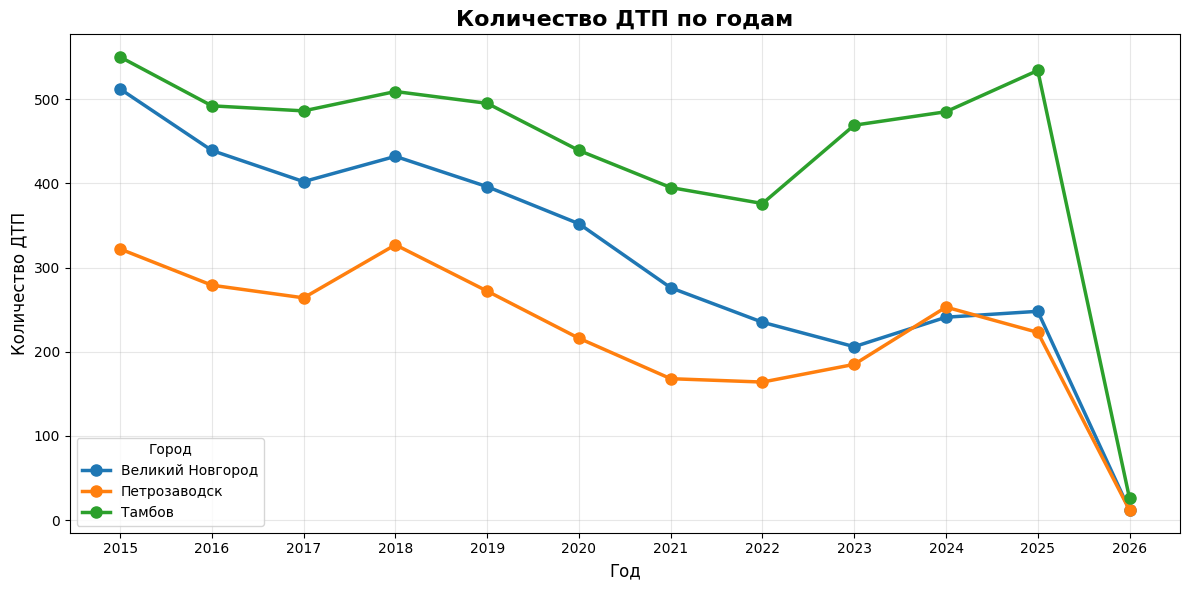

In [27]:
# график - Количество ДТП по годам и городам
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

pivot_dtp.plot(kind='line', marker='o', linewidth=2.5, markersize=8, ax=plt.gca())

plt.title('Количество ДТП по годам', fontsize=16, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество ДТП', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Город')
plt.xticks(pivot_dtp.index)

plt.tight_layout()
plt.show()

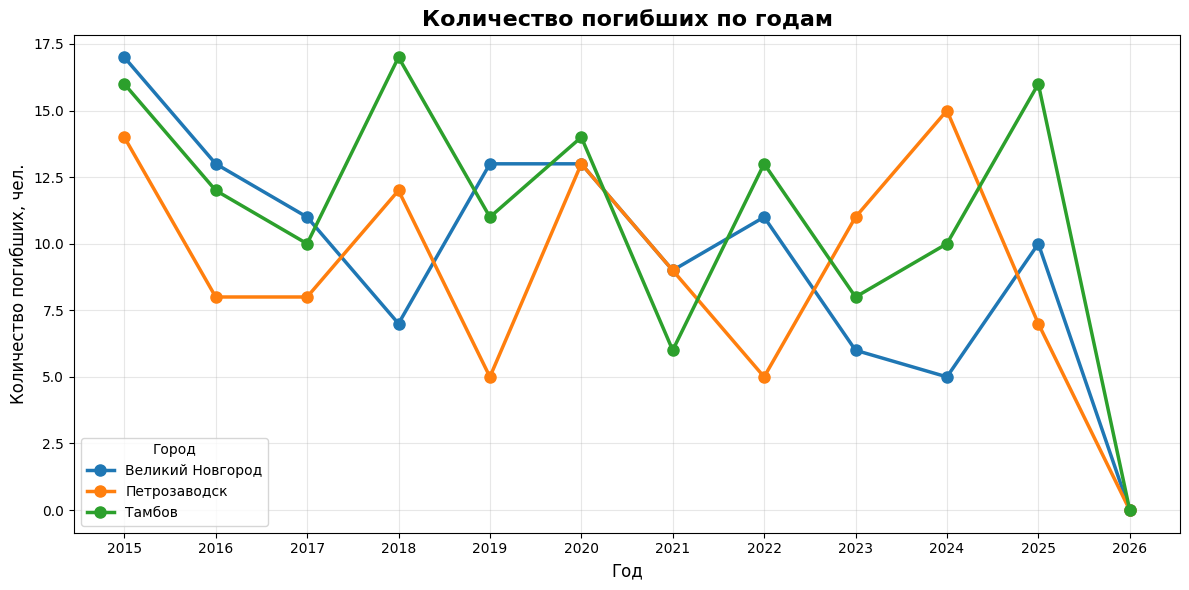

In [28]:
# график - Количество погибших по годам и городам
plt.figure(figsize=(12, 6))

pivot_fatal.plot(kind='line', marker='o', linewidth=2.5, markersize=8, ax=plt.gca())

plt.title('Количество погибших по годам', fontsize=16, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество погибших, чел.', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Город')
plt.xticks(pivot_fatal.index)

plt.tight_layout()
plt.show()

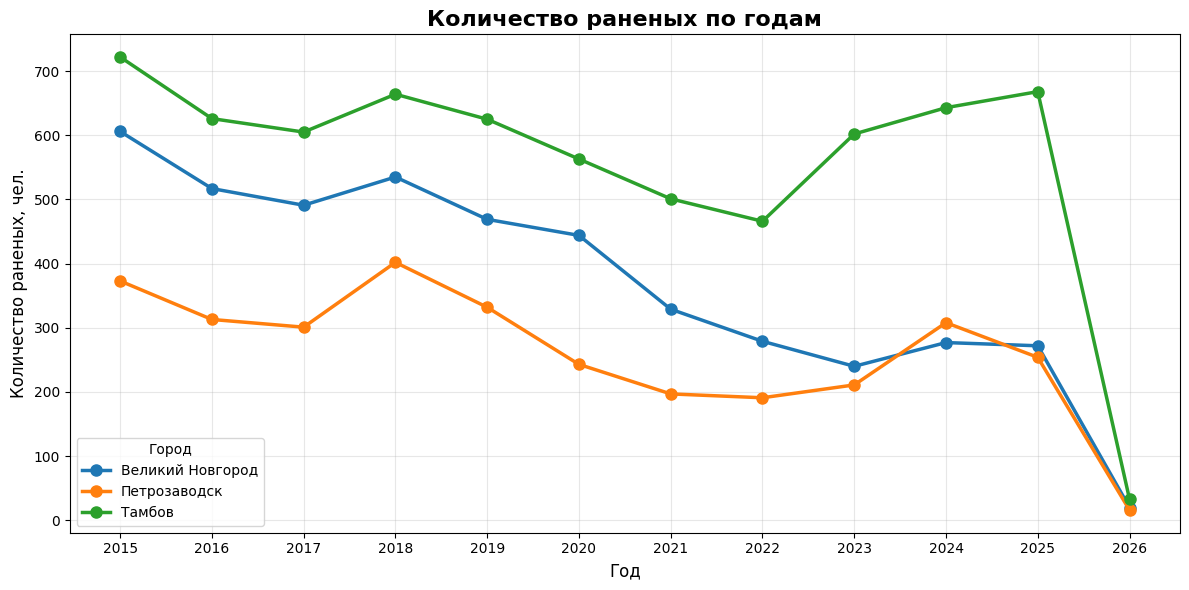

In [29]:
# график - Количество раненых по годам и городам
plt.figure(figsize=(12, 6))

pivot_injured.plot(kind='line', marker='o', linewidth=2.5, markersize=8, ax=plt.gca())

plt.title('Количество раненых по годам', fontsize=16, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество раненых, чел.', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Город')
plt.xticks(pivot_injured.index)

plt.tight_layout()
plt.show()

Промежуточные выводы: 

всего 11692 ДТП за 11 лет, 97.97% ДТП с ранеными и только 2.81% - с погибшими. Cмертельные случаи — редкое, но крайне важное событие.

Графики наглядно показывают, что после 2017-2018 годов количество ДТП, погибших и раненых пошло на спад, но с 2023-2024 годов снова наблюдается рост. Города имеют разные тренды: статистика Тамбова в 2025 году (534 случая) практически вернулась к уровню ДТП 2015 года (550 случаев), несмотря на временный спад в период пандемии COVID 19 в 2020-2022, в то время как количество ДТП в Великом Новгороде значительно снизилось с 2015 года (512 случаев) против 2025 года (248 случаев).

In [30]:
# Виды ДТП
dtp_type_counts = dtp_main['dtp_type'].value_counts()
dtp_type_counts

dtp_type
Столкновение                                                                                                 5678
Наезд на пешехода                                                                                            3578
Падение пассажира                                                                                             704
Наезд на велосипедиста                                                                                        576
Наезд на препятствие                                                                                          445
Наезд на стоящее ТС                                                                                           315
Опрокидывание                                                                                                 170
Съезд с дороги                                                                                                119
Иной вид ДТП                                                                   

<Figure size 1000x600 with 0 Axes>

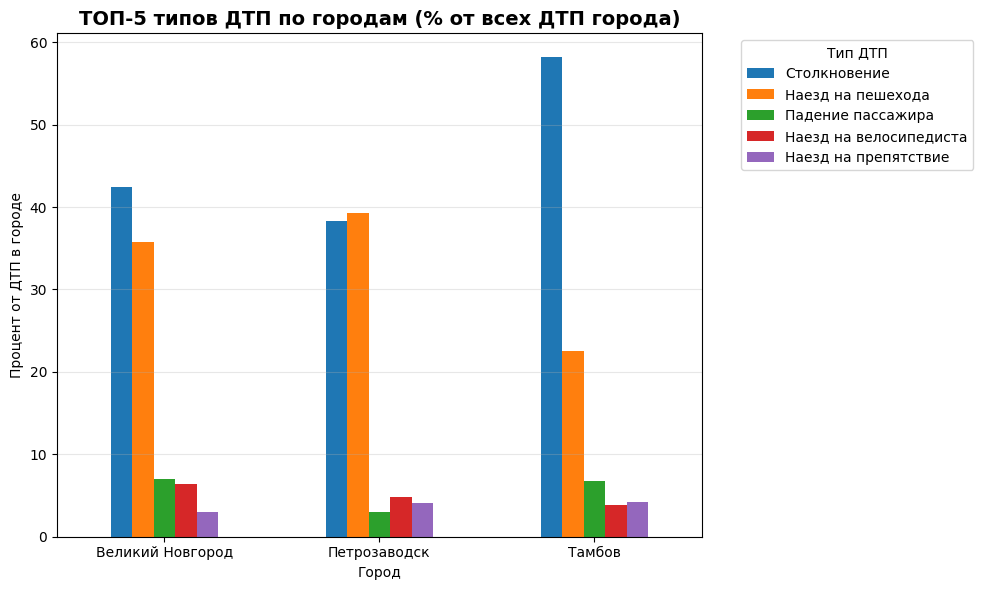

In [37]:
# топ-5 типов ДТП
dtp_type_pivot = dtp_main.groupby(['district', 'dtp_type']).size().unstack(fill_value=0)
dtp_type_pivot_pct = dtp_type_pivot.div(dtp_type_pivot.sum(axis=1), axis=0) * 100
top5_types = dtp_main['dtp_type'].value_counts().head(5).index.tolist()
plot_data = dtp_type_pivot_pct[top5_types]

plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', figsize=(10, 6))
plt.title('ТОП-5 типов ДТП по городам (% от всех ДТП города)', fontsize=14, fontweight='bold')
plt.xlabel('Город')
plt.ylabel('Процент от ДТП в городе')
plt.legend(title='Тип ДТП', bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()


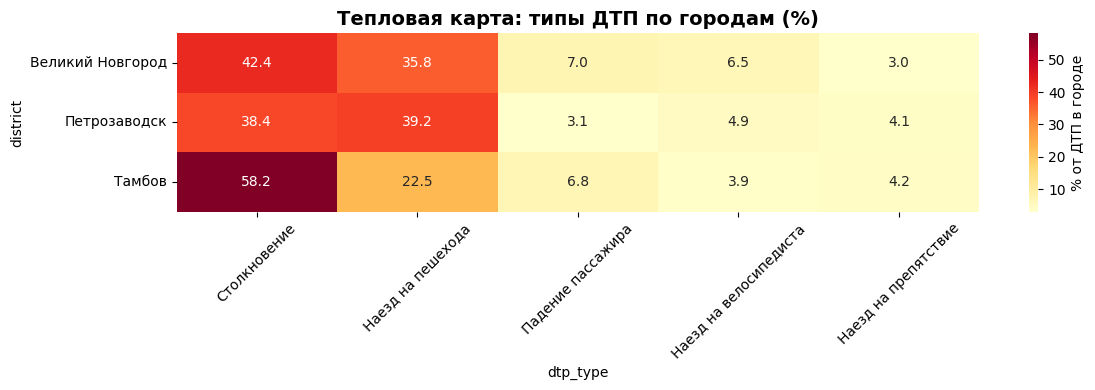

In [38]:
plt.figure(figsize=(12, 4))
import seaborn as sns
sns.heatmap(dtp_type_pivot_pct[top5_types], annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': '% от ДТП в городе'})
plt.title('Тепловая карта: типы ДТП по городам (%)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [39]:
# Виды ДТП по городам
dtp_type_stats = dtp_main.groupby('district')['dtp_type'].value_counts().reset_index(name='Количество')
dtp_type_stats['Процент'] = dtp_type_stats.groupby('district')['Количество'].transform(lambda x: (x / x.sum() * 100).round(1))

dtp_type_stats = dtp_type_stats.sort_values(['district', 'Количество'], ascending=[True, False])

print(dtp_type_stats.to_string(index=False))

        district                                                                                                  dtp_type  Количество  Процент
Великий Новгород                                                                                              Столкновение        1591     42.4
Великий Новгород                                                                                         Наезд на пешехода        1342     35.8
Великий Новгород                                                                                         Падение пассажира         264      7.0
Великий Новгород                                                                                    Наезд на велосипедиста         242      6.5
Великий Новгород                                                                                      Наезд на препятствие         113      3.0
Великий Новгород                                                                                             Опрокидывание          65  

Промежуточные выводы:

«Столкновение» и «Наезд на пешехода» - абсолютные лидеры.
 
Статистика показывает региональные различия: в Тамбове и Великом Новгороде преобладают столкновения (58.2% и 42.4%), затем - наезды на пешеходов (22.5% и 35.8%) и падение пешеходов (6.8% и 7.0%), а в Петрозаводске преобладают наезды на пешеходов (39.2%), затем - столкновения (38.4%) и наезды на велосипедистов (4.9%). 

*1.2 Временные паттерны ДТП*

In [40]:
# Соединение ДТП с почасовой погодой

dtp_main['datetime'] = pd.to_datetime(dtp_main['date'].astype(str) + ' ' + dtp_main['time'].astype(str))
dtp_main['date'] = pd.to_datetime(dtp_main['date'])  # для дневной агрегации
dtp_main['hour'] = dtp_main['datetime'].dt.hour  # для почасового анализа
dtp_main['day_of_week'] = dtp_main['datetime'].dt.dayofweek  # дни недели
dtp_main['datetime_hour'] = dtp_main['datetime'].dt.floor('h')

weather_hourly['datetime'] = pd.to_datetime(weather_hourly['datetime']).dt.tz_localize(None)



weather_columns = [
    'city_id', 'datetime',
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature',
    'precipitation', 'rain', 'snowfall', 'snow_depth',
    'pressure_msl', 'surface_pressure',
    'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    'wind_speed_10m', 'wind_speed_100m', 'wind_direction_100m', 'wind_gusts_10m'
]
dtp_with_weather = pd.merge(
    dtp_main[['kart_id', 'city_id', 'district', 'datetime_hour', 'fatalities', 'injured', 'date', 'hour', 'day_of_week']],
    weather_hourly[weather_columns],
    left_on=['city_id', 'datetime_hour'],
    right_on=['city_id', 'datetime'],
    how='left'
)

dtp_with_weather.head()

,kart_id,city_id,district,datetime_hour,fatalities,injured,date,hour,day_of_week,datetime,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_100m,wind_gusts_10m
0,161368315,763e286c-fc7b-4d1b-b2e1-463fced954be,Петрозаводск,2015-01-31 15:00:00,0,1,2015-01-31,15,5,2015-01-31 15:00:00,-1.9,92.0,-3.1,-6.8,0.0,0.0,0.07,0.17,998.2,990.1,100.0,99.0,85.0,100.0,15.8,25.3,110.0,31.3
1,161361156,763e286c-fc7b-4d1b-b2e1-463fced954be,Петрозаводск,2015-01-30 20:00:00,0,1,2015-01-30,20,4,2015-01-30 20:00:00,-1.3,90.0,-2.7,-6.0,0.0,0.0,0.07,0.17,997.4,989.3,99.0,96.0,52.0,20.0,15.2,26.8,186.0,33.1
2,161354221,763e286c-fc7b-4d1b-b2e1-463fced954be,Петрозаводск,2015-01-30 18:00:00,0,1,2015-01-30,18,4,2015-01-30 18:00:00,-1.1,89.0,-2.6,-5.8,0.2,0.0,0.14,0.17,997.3,989.2,100.0,99.0,99.0,98.0,15.5,27.0,178.0,32.4
3,161356960,763e286c-fc7b-4d1b-b2e1-463fced954be,Петрозаводск,2015-01-30 23:00:00,0,1,2015-01-30,23,4,2015-01-30 23:00:00,-1.3,90.0,-2.7,-5.6,0.0,0.0,0.00,0.17,998.7,990.6,100.0,100.0,0.0,82.0,12.6,22.7,198.0,28.1
4,161014447,763e286c-fc7b-4d1b-b2e1-463fced954be,Петрозаводск,2015-01-29 17:00:00,0,1,2015-01-29,17,3,2015-01-29 17:00:00,-3.2,85.0,-5.4,-8.0,0.0,0.0,0.00,0.17,996.5,988.3,100.0,96.0,1.0,80.0,13.2,23.3,197.0,30.2


*

In [41]:
dtp_with_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 11692 entries, 0 to 11691
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   kart_id               11692 non-null  int64         
 1   city_id               11692 non-null  object        
 2   district              11692 non-null  str           
 3   datetime_hour         11692 non-null  datetime64[us]
 4   fatalities            11692 non-null  int64         
 5   injured               11692 non-null  int64         
 6   date                  11692 non-null  datetime64[s] 
 7   hour                  11692 non-null  int32         
 8   day_of_week           11692 non-null  int32         
 9   datetime              11642 non-null  datetime64[us]
 10  temperature_2m        11642 non-null  float64       
 11  relative_humidity_2m  11642 non-null  float64       
 12  dew_point_2m          11642 non-null  float64       
 13  apparent_temperature  11642

In [106]:
# Добавление информации о дорожных условиях из dtp_road_conditions
road_conditions_prep = dtp_road_conditions[['kart_id', 'road_surface', 'light_conditions', 
                                           'weather_conditions', 'road_deficiencies', 
                                           'traffic_scheme', 'traffic_objects']].copy()

# Преобразуем списки в строки 
for col in ['weather_conditions', 'road_deficiencies', 'traffic_scheme', 'traffic_objects']:
    road_conditions_prep[col] = road_conditions_prep[col].apply(
        lambda x: ', '.join(eval(x)) if isinstance(x, str) and x.startswith('[') else x
    )

dtp_with_weather = pd.merge(
    dtp_with_weather,
    road_conditions_prep,
    on='kart_id',
    how='left'
)

dtp_with_weather.head()

,kart_id,city_id,district,datetime_hour,fatalities,injured,date,hour,day_of_week,datetime,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_100m,wind_gusts_10m,road_surface_x,light_conditions_x,weather_conditions_x,road_deficiencies_x,traffic_scheme_x,traffic_objects_x,road_surface_y,light_conditions_y,weather_conditions_y,road_deficiencies_y,traffic_scheme_y,traffic_objects_y,month,road_surface,light_conditions,weather_conditions,road_deficiencies,traffic_scheme,traffic_objects
0,161368315,763e286c-fc7b-4d1b-b2e1-463fced954be,Петрозаводск,2015-01-31 15:00:00,0,1,2015-01-31,15,5,2015-01-31 15:00:00,-1.9,92.0,-3.1,-6.8,0.0,0.0,0.07,0.17,998.2,990.1,100.0,99.0,85.0,100.0,15.8,25.3,110.0,31.3,Обработанное противогололедными материалами,Светлое время суток,[Пасмурно],"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]",[Перегон (нет объектов на месте ДТП)],[АЗС],Обработанное противогололедными материалами,Светлое время суток,[Пасмурно],"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]",[Перегон (нет объектов на месте ДТП)],[АЗС],1,Обработанное противогололедными материалами,Светлое время суток,[Пасмурно],"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]",[Перегон (нет объектов на месте ДТП)],[АЗС]
1,161361156,763e286c-fc7b-4d1b-b2e1-463fced954be,Петрозаводск,2015-01-30 20:00:00,0,1,2015-01-30,20,4,2015-01-30 20:00:00,-1.3,90.0,-2.7,-6.0,0.0,0.0,0.07,0.17,997.4,989.3,99.0,96.0,52.0,20.0,15.2,26.8,186.0,33.1,Мокрое,"В темное время суток, освещение включено",[Пасмурно],[Не установлены],"[Перегон (нет объектов на месте ДТП), Нерегулируемый пешеходный переход]",[Многоквартирные жилые дома],Мокрое,"В темное время суток, освещение включено",[Пасмурно],[Не установлены],"[Перегон (нет объектов на месте ДТП), Нерегулируемый пешеходный переход]",[Многоквартирные жилые дома],1,Мокрое,"В темное время суток, освещение включено",[Пасмурно],[Не установлены],"[Перегон (нет объектов на месте ДТП), Нерегулируемый пешеходный переход]",[Многоквартирные жилые дома]
2,161354221,763e286c-fc7b-4d1b-b2e1-463fced954be,Петрозаводск,2015-01-30 18:00:00,0,1,2015-01-30,18,4,2015-01-30 18:00:00,-1.1,89.0,-2.6,-5.8,0.2,0.0,0.14,0.17,997.3,989.2,100.0,99.0,99.0,98.0,15.5,27.0,178.0,32.4,Мокрое,"В темное время суток, освещение включено",[Пасмурно],"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]",[Перегон (нет объектов на месте ДТП)],[Отсутствие в непосредственной близости объектов УДС и объектов притяжения],Мокрое,"В темное время суток, освещение включено",[Пасмурно],"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]",[Перегон (нет объектов на месте ДТП)],[Отсутствие в непосредственной близости объектов УДС и объектов притяжения],1,Мокрое,"В темное время суток, освещение включено",[Пасмурно],"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]",[Перегон (нет объектов на месте ДТП)],[Отсутствие в непосредственной близости объектов УДС и объектов притяжения]
3,161356960,763e286c-fc7b-4d1b-b2e1-463fced954be,Петрозаводск,2015-01-30 23:00:00,0,1,2015-01-30,23,4,2015-01-30 23:00:00,-1.3,90.0,-2.7,-5.6,0.0,0.0,0.00,0.17,998.7,990.6,100.0,100.0,0.0,82.0,12.6,22.7,198.0,28.1,Обработанное противогололедными материалами,"В темное время суток, освещение включено",[Пасмурно],"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]","[Перегон (нет объектов на месте ДТП), Нерегулируемый перекрёсток неравнозначных улиц (дорог)]",[Жилые дома индивидуальной застройки],Обработанное противогололедными материалами,"В темное время суток, освещение включено",[Пасмурно],"[Отсутствие, плохая различимость горизонтальной разметки проезжей части]","[Перегон (нет объектов на месте ДТП), Нерегулируемый перекрёсток неравнозначных улиц (дорог)]",[Жил

In [107]:
dtp_with_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 11692 entries, 0 to 11691
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   kart_id               11692 non-null  int64         
 1   city_id               11692 non-null  object        
 2   district              11692 non-null  str           
 3   datetime_hour         11692 non-null  datetime64[us]
 4   fatalities            11692 non-null  int64         
 5   injured               11692 non-null  int64         
 6   date                  11692 non-null  datetime64[s] 
 7   hour                  11692 non-null  int32         
 8   day_of_week           11692 non-null  int32         
 9   datetime              11642 non-null  datetime64[us]
 10  temperature_2m        11642 non-null  float64       
 11  relative_humidity_2m  11642 non-null  float64       
 12  dew_point_2m          11642 non-null  float64       
 13  apparent_temperature  11642

In [45]:
# ДТП по часам
dtp_hours = dtp_with_weather.groupby('hour').agg({
    'kart_id': 'count',
    'fatalities': 'sum',
    'injured': 'sum'
})

dtp_hours

,kart_id,fatalities,injured
hour,,,
0,168,13,223
1,125,8,164
2,98,12,129
3,81,13,101
4,73,8,95
5,71,3,96
6,129,6,163
7,484,15,587
8,721,16,862


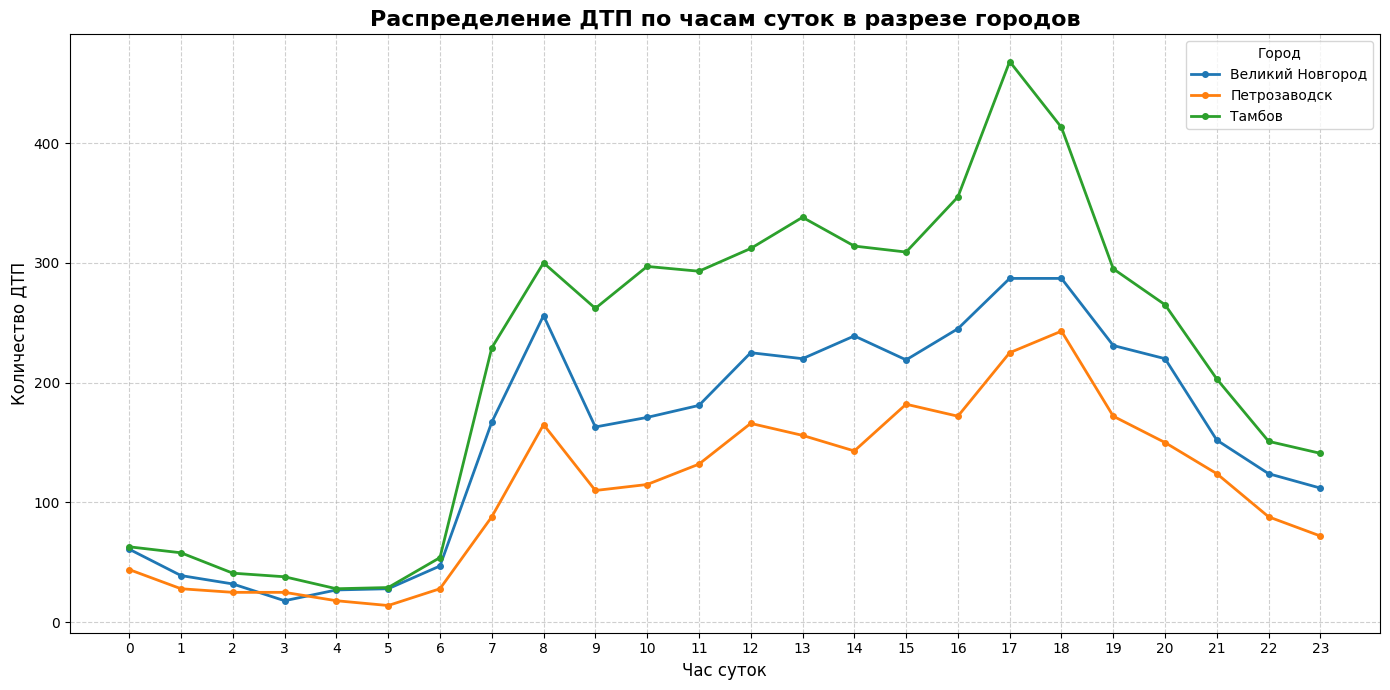

In [46]:
# Разделение по часам и городам
hourly_by_city = dtp_with_weather.groupby(['district', 'hour']).size().reset_index(name='dtp_count')

plt.figure(figsize=(14, 7))

for city in hourly_by_city['district'].unique():
    city_data = hourly_by_city[hourly_by_city['district'] == city]
    plt.plot(city_data['hour'], city_data['dtp_count'], marker='o', markersize=4, linewidth=2, label=city)

plt.title('Распределение ДТП по часам суток в разрезе городов', fontsize=16, fontweight='bold')
plt.xlabel('Час суток', fontsize=12)
plt.ylabel('Количество ДТП', fontsize=12)
plt.xticks(range(0, 24))  # Показываем все часы на оси X
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Город', fontsize=10)
plt.tight_layout()
plt.show()

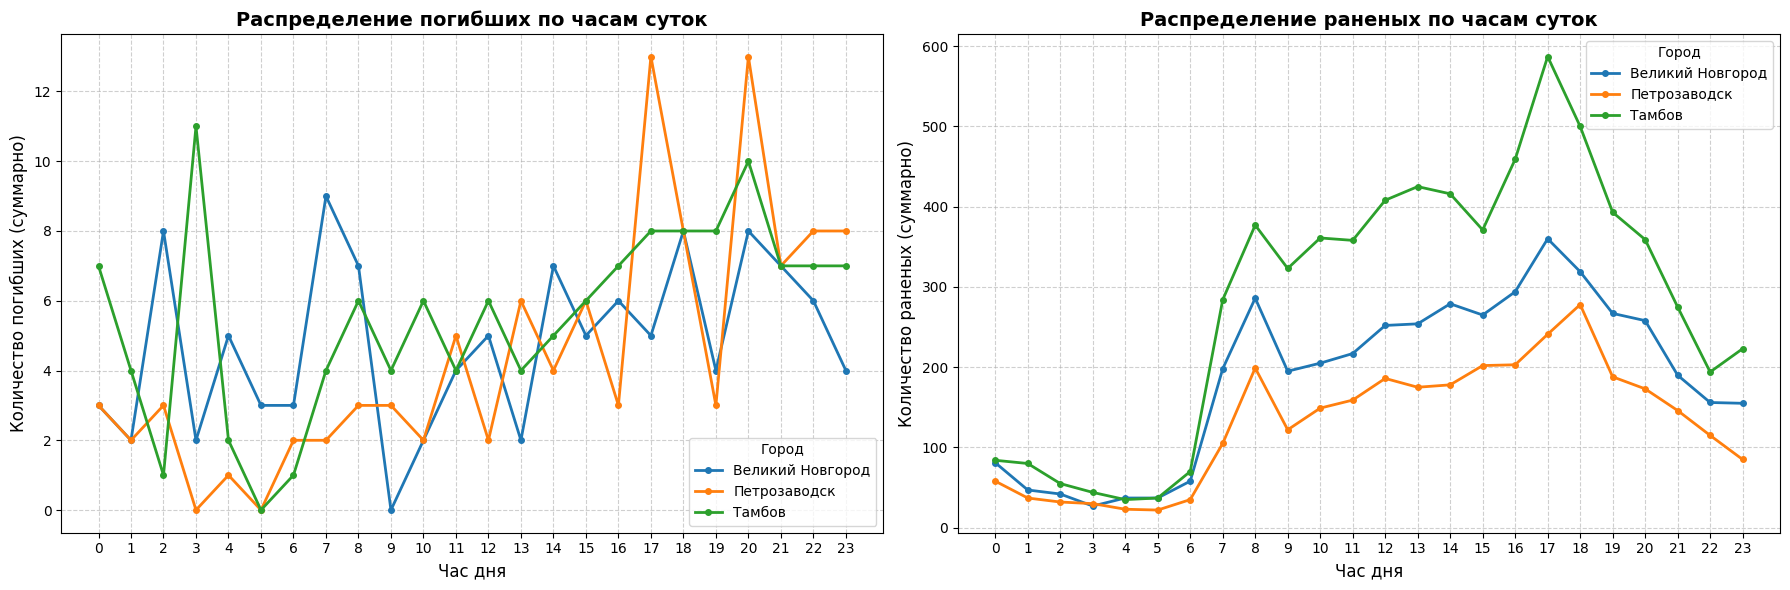

In [49]:
# Анализ тяжести ДТП - погибшие и раненые в разрезе городов

hourly_fatal_by_city = dtp_with_weather.groupby(['district', 'hour'])['fatalities'].sum().reset_index()
hourly_injured_by_city = dtp_with_weather.groupby(['district', 'hour'])['injured'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for city in hourly_fatal_by_city['district'].unique():
    city_data = hourly_fatal_by_city[hourly_fatal_by_city['district'] == city]
    axes[0].plot(city_data['hour'], city_data['fatalities'], marker='o', markersize=4, linewidth=2, label=city)

axes[0].set_title('Распределение погибших по часам суток', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Час дня', fontsize=12)
axes[0].set_ylabel('Количество погибших (суммарно)', fontsize=12)
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(title='Город')

for city in hourly_injured_by_city['district'].unique():
    city_data = hourly_injured_by_city[hourly_injured_by_city['district'] == city]
    axes[1].plot(city_data['hour'], city_data['injured'], marker='o', markersize=4, linewidth=2, label=city)

axes[1].set_title('Распределение раненых по часам суток', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Час дня', fontsize=12)
axes[1].set_ylabel('Количество раненых (суммарно)', fontsize=12)
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='Город')

plt.tight_layout()
plt.show()


Промежуточные выводы:

Утренний пик (7-9 утра): Резкий скачок с 6:00 (129) до 8:00 (721). Это классический "час пик", когда люди едут на работу.
Дневное плато (10-16 часов): Количество ДТП держится на стабильно высоком уровне (580-770). Много перемещений в течение дня.
Вечерний пик (17-18 часов): Максимум аварийности приходится на 17:00 (980 ДТП) и 18:00 (943). Это самый опасный вечерний час пик, когда все возвращаются с работы.

С 0:00 до 5:00 ДТП мало (70-160), но количество погибших довольно большое:
- в 17:00 при 980 ДТП погибло 26 человек;
- в 0:00 при 168 ДТП погибло 13 человек.

Ночью ДТП происходит в 6 раз реже, но погибает в них всего в 2 раза меньше людей. Это говорит о том, что ночные ДТП гораздо более смертоносны. Это может быть связано с высокой скоростью, алкоголем, усталостью водителей.

Общая динамика количества ДТП и пострадавших в разрезе городов сходна, динамика количества погибших сильно колеблется в течение дня во всех городах, но надо иметь ввиду небольшой размах этого показателя в течении дня (от 0 до 13 человек) в разрезе городов и времени суток. 

            district  day_of_week  kart_id  fatalities  injured day_name
0   Великий Новгород            0      616          11      747       Пн
1   Великий Новгород            1      553          18      650       Вт
2   Великий Новгород            2      569          20      666       Ср
3   Великий Новгород            3      541          13      632       Чт
4   Великий Новгород            4      604          24      698       Пт
5   Великий Новгород            5      496          10      627       Сб
6   Великий Новгород            6      372          19      459       Вс
7       Петрозаводск            0      426          22      498       Пн
8       Петрозаводск            1      396           8      465       Вт
9       Петрозаводск            2      390          11      448       Ср
10      Петрозаводск            3      355          10      414       Чт
11      Петрозаводск            4      451          17      502       Пт
12      Петрозаводск            5      335         

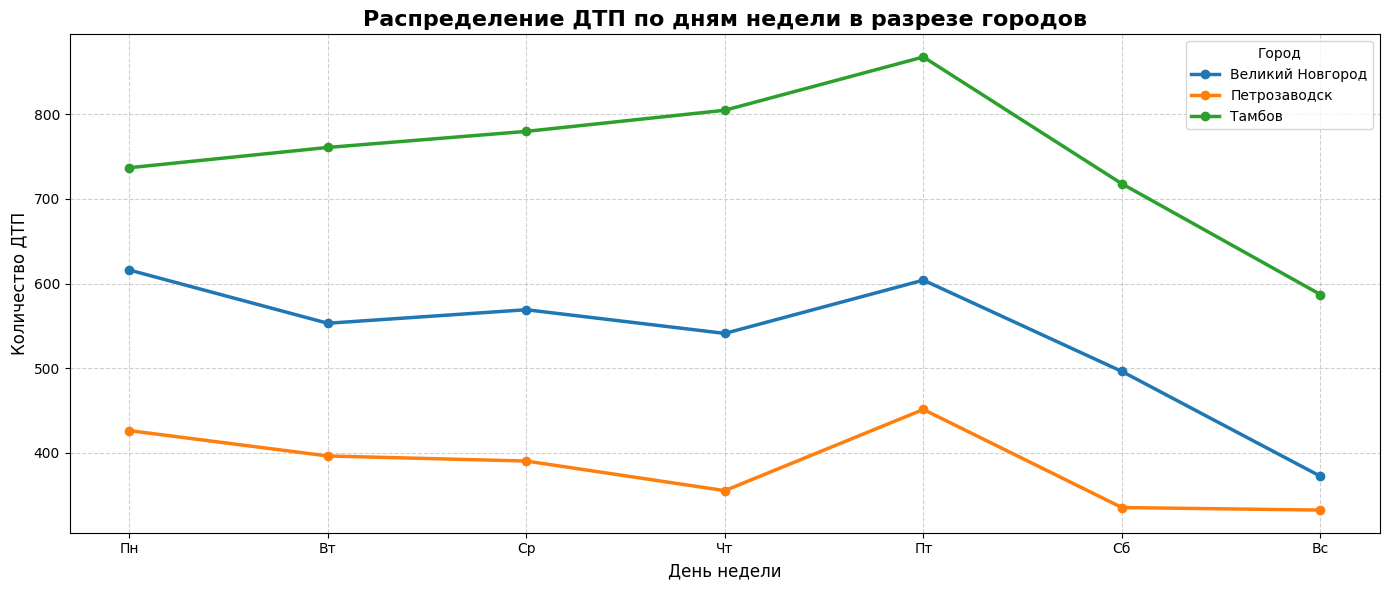

In [67]:
# Анализ по дням недели
day_names = {
    0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 
    4: 'Пт', 5: 'Сб', 6: 'Вс'
}

weekly_by_city = dtp_with_weather.groupby(['district', 'day_of_week']).agg({
    'kart_id': 'count',
    'fatalities': 'sum',
    'injured': 'sum'
}).reset_index()
weekly_by_city['day_name'] = weekly_by_city['day_of_week'].map(day_names)
day_order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekly_by_city['day_name'] = pd.Categorical(weekly_by_city['day_name'], categories=day_order, ordered=True)
weekly_by_city = weekly_by_city.sort_values(['district', 'day_name'])

print(weekly_by_city)

plt.figure(figsize=(14, 6))

for city in weekly_by_city['district'].unique():
    city_data = weekly_by_city[weekly_by_city['district'] == city]
    plt.plot(city_data['day_name'], city_data['kart_id'], 
             marker='o', markersize=6, linewidth=2.5, label=city)

plt.title('Распределение ДТП по дням недели в разрезе городов', fontsize=16, fontweight='bold')
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Количество ДТП', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Город', fontsize=10)
plt.tight_layout()
plt.show()


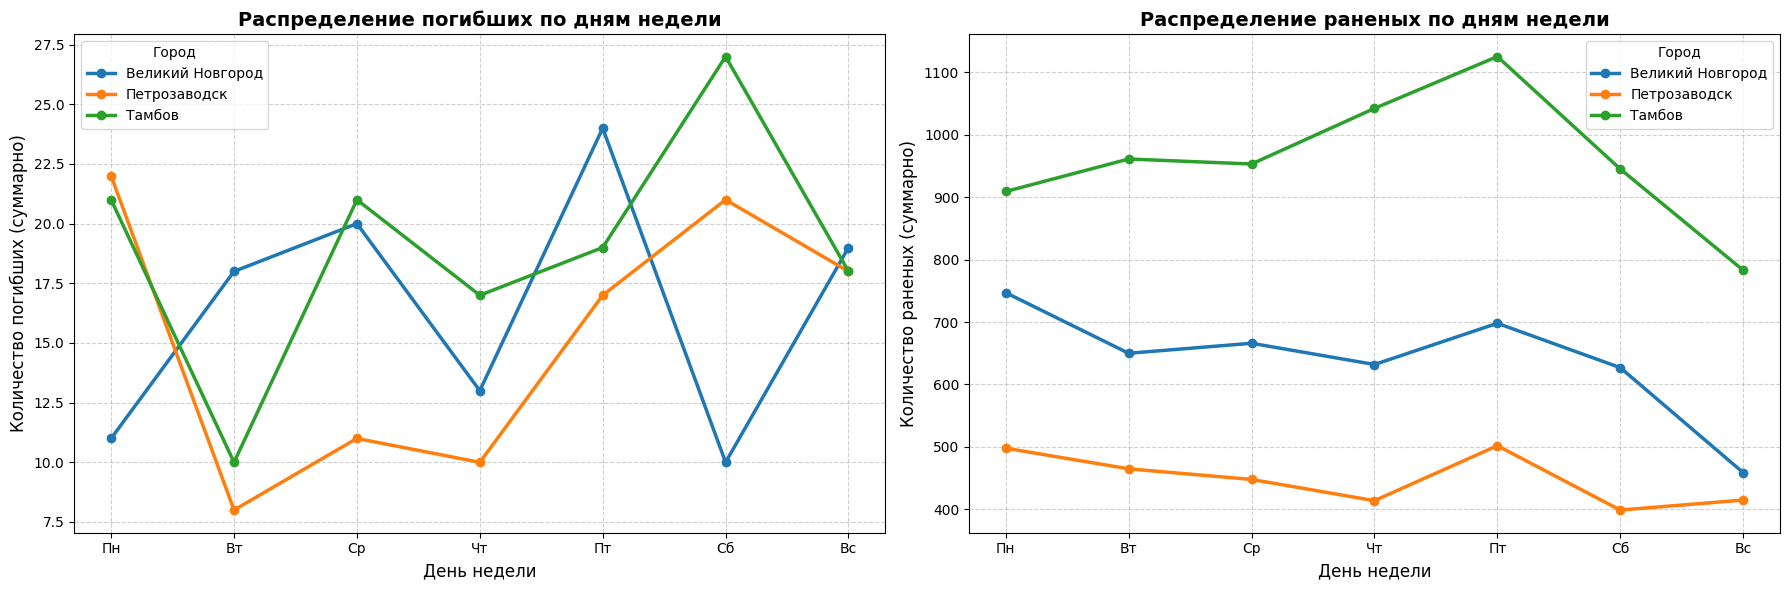

In [51]:
# Тяжесть ДТП по дням недели
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Погибшие 
for city in weekly_by_city['district'].unique():
    city_data = weekly_by_city[weekly_by_city['district'] == city]
    axes[0].plot(city_data['day_name'], city_data['fatalities'], 
                marker='o', markersize=6, linewidth=2.5, label=city)
axes[0].set_title('Распределение погибших по дням недели', fontsize=14, fontweight='bold')
axes[0].set_xlabel('День недели', fontsize=12)
axes[0].set_ylabel('Количество погибших (суммарно)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(title='Город')

# Раненые 
for city in weekly_by_city['district'].unique():
    city_data = weekly_by_city[weekly_by_city['district'] == city]
    axes[1].plot(city_data['day_name'], city_data['injured'], 
                marker='o', markersize=6, linewidth=2.5, label=city)
axes[1].set_title('Распределение раненых по дням недели', fontsize=14, fontweight='bold')
axes[1].set_xlabel('День недели', fontsize=12)
axes[1].set_ylabel('Количество раненых (суммарно)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='Город')

plt.tight_layout()
plt.show()


Промежуточные выводы:

Во всех городах графики повторяют общероссийскую логику (двугорбая кривая - утро и вечер), но в Тамбове вечерний пик выражен ярче, чем в Великом Новгороде и Петрозаводске, что может быть связано с разной плотностью трафика или структурой дорог.


            district  month  kart_id  fatalities  injured month_name
0   Великий Новгород      1      271          11      353        Янв
1   Великий Новгород      2      233           8      281        Фев
2   Великий Новгород      3      264          12      314        Мар
3   Великий Новгород      4      256           9      311        Апр
4   Великий Новгород      5      279           4      314        Май
5   Великий Новгород      6      337          13      384        Июн
6   Великий Новгород      7      300           5      356        Июл
7   Великий Новгород      8      351           7      421        Авг
8   Великий Новгород      9      391           4      483        Сен
9   Великий Новгород     10      346          13      409        Окт
10  Великий Новгород     11      353          13      422        Ноя
11  Великий Новгород     12      370          16      431        Дек
12      Петрозаводск      1      194           8      240        Янв
13      Петрозаводск      2      1

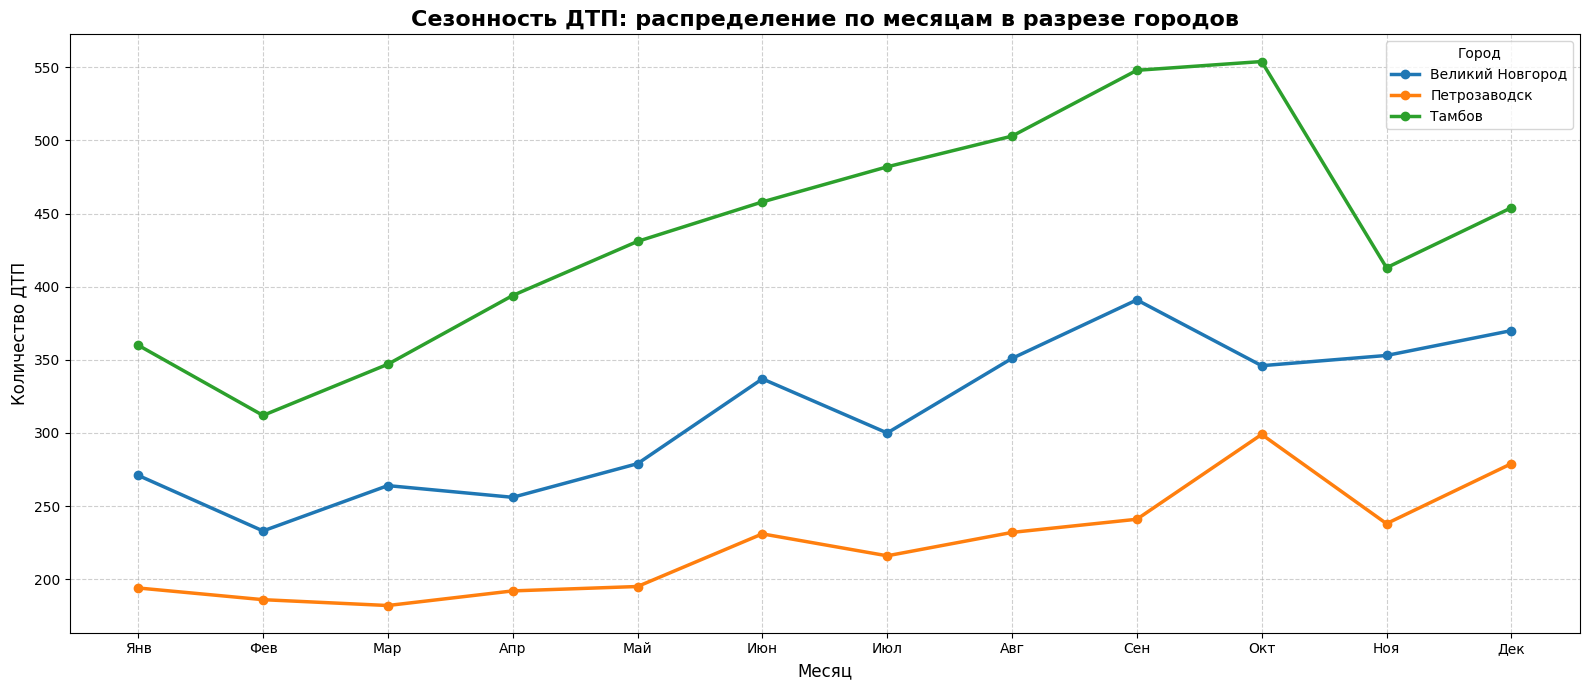

In [53]:
# Сезонная динамика

month_names = {
    1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн',
    7: 'Июл', 8: 'Авг', 9: 'Сен', 10: 'Окт', 11: 'Ноя', 12: 'Дек'
}

dtp_with_weather['month'] = dtp_with_weather['date'].dt.month

monthly_by_city = dtp_with_weather.groupby(['district', 'month']).agg({
    'kart_id': 'count',
    'fatalities': 'sum',
    'injured': 'sum'
}).reset_index()

monthly_by_city['month_name'] = monthly_by_city['month'].map(month_names)
month_order = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
monthly_by_city['month_name'] = pd.Categorical(monthly_by_city['month_name'], 
                                               categories=month_order, ordered=True)
monthly_by_city = monthly_by_city.sort_values(['district', 'month_name'])

print(monthly_by_city)

plt.figure(figsize=(16, 7))

for city in monthly_by_city['district'].unique():
    city_data = monthly_by_city[monthly_by_city['district'] == city]
    plt.plot(city_data['month_name'], city_data['kart_id'], 
             marker='o', markersize=6, linewidth=2.5, label=city)

plt.title('Сезонность ДТП: распределение по месяцам в разрезе городов', fontsize=16, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество ДТП', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Город', fontsize=10)
plt.tight_layout()
plt.show()

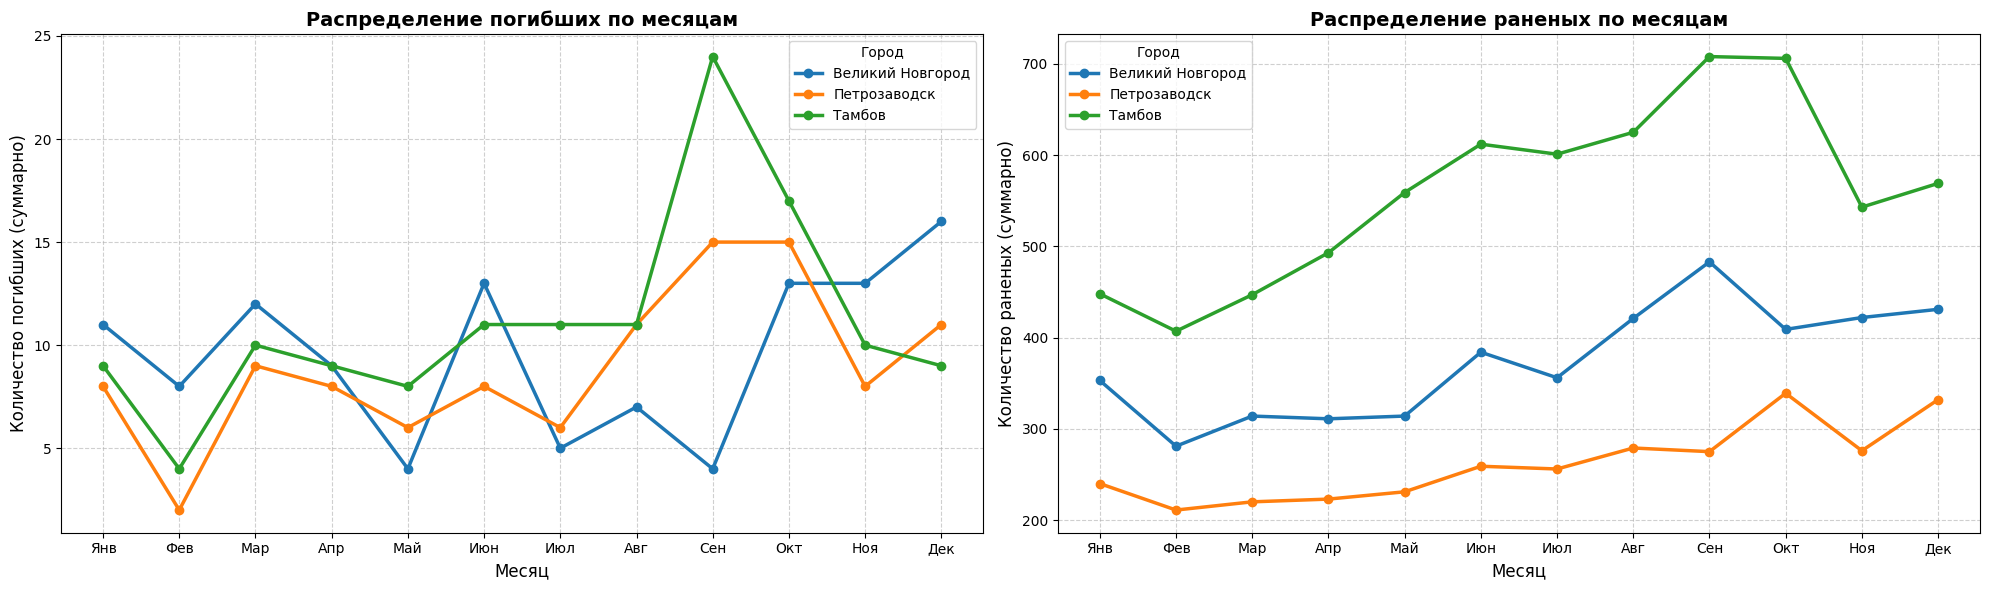

In [54]:
# Тяжесть ДТП по месяцам
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Погибшие 
for city in monthly_by_city['district'].unique():
    city_data = monthly_by_city[monthly_by_city['district'] == city]
    axes[0].plot(city_data['month_name'], city_data['fatalities'], 
                marker='o', markersize=6, linewidth=2.5, label=city)
axes[0].set_title('Распределение погибших по месяцам', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Месяц', fontsize=12)
axes[0].set_ylabel('Количество погибших (суммарно)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(title='Город')

# Раненые 
for city in monthly_by_city['district'].unique():
    city_data = monthly_by_city[monthly_by_city['district'] == city]
    axes[1].plot(city_data['month_name'], city_data['injured'], 
                marker='o', markersize=6, linewidth=2.5, label=city)
axes[1].set_title('Распределение раненых по месяцам', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Месяц', fontsize=12)
axes[1].set_ylabel('Количество раненых (суммарно)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='Город')

plt.tight_layout()
plt.show()

Промежуточные выводы:

Осенне-весенний пик. Количество ДТП растет в сентябре-октябре, а также в марте–апреле.
Сентябрь и октябрь лидируют по числу аварий. Это может быть связано с началом учебного года, ухудшением погоды (дожди, сокращение светового дня) и увеличением количества машин на дорогах после лета.
В марте также наблюдается рост, вероятно, из-за смены сезонов и сложных дорожных условий (гололед, перепады температур).

Провал в январе-феврале. Меньше всего ДТП в январе и феврале. Несмотря на плохую погоду и снег, трафик в эти месяцы традиционно ниже (праздники, морозы, меньше поездок), что снижает абсолютное число аварий.

Летняя стабильность. В июне–августе количество ДТП держится на среднем уровне. При этом в августе в некоторых городах (например, Тамбов) фиксируется рост, что может быть связано с возвращением людей из отпусков и подготовкой к учебному году.

Географические различия: 
- в Петрозаводске пик ДТП приходится на октябрь (299 ДТП), что, вероятно, связано с ранним наступлением зимы, гололедом и снегопадами.
- в Великом Новгороде и Тамбове пик более плавный и приходится на сентябрь–октябрь.

Тяжесть последствий по месяцам. Наибольшее количество погибших фиксируется в сентябре–октябре, что совпадает с пиком аварийности.
В Петрозаводске заметен всплеск раненых и погибших в октябре (15 погибших, 339 раненых), что подтверждает опасность переходного периода между осенью и зимой.

*1.3 Анализ участников ДТП*

In [65]:
# Общее распределение участников ДТП
role_distribution = dtp_participants['role'].value_counts().reset_index()
role_distribution.columns = ['Роль', 'Количество']
role_distribution['Процент'] = (role_distribution['Количество'] / len(dtp_participants) * 100).round(2)

role_distribution = role_distribution.sort_values('Количество', ascending=False).reset_index(drop=True)

print(role_distribution.to_string(index=False))

                                                                                                                                                                          Роль  Количество  Процент
                                                                                                                                                                      Водитель       18735    62.48
                                                                                                                                                                      Пассажир        6721    22.42
                                                                                                                                                                       Пешеход        3808    12.70
                                                                                                                                                                  Велосипедист         535     1.78
                    

In [70]:
# Роли по городам
kart_to_city = dict(zip(dtp_main['kart_id'], dtp_main['city_name']))
dtp_participants['city_name'] = dtp_participants['kart_id'].map(kart_to_city)

role_by_city = pd.crosstab(
    dtp_participants['city_name'], 
    dtp_participants['role'],
    normalize='index'
) * 100

print(role_by_city.round(2).T)

city_name                                                                                                                                                                       Великий Новгород  \
role                                                                                                                                                                                               
Велосипедист                                                                                                                                                                                2.52   
Велосипедист (не применяется)                                                                                                                                                               0.14   
Водитель                                                                                                                                                                                   62.90   
Всадник             

In [71]:
cities = dtp_participants['city_name'].dropna().unique()

for city in cities:
    city_data = dtp_participants[dtp_participants['city_name'] == city]
    role_dist = city_data['role'].value_counts()
    role_pct = (role_dist / len(city_data) * 100).round(2)
    
    city_df = pd.DataFrame({
        'Роль': role_dist.index,
        'Количество': role_dist.values,
        'Процент': role_pct.values
    }).sort_values('Количество', ascending=False).reset_index(drop=True)
    
    print(f"\n--- {city} ---")
    print(city_df.to_string(index=False))
    print(f"Всего участников: {len(city_data):,}")


--- Петрозаводск ---
                                                                                                                            Роль  Количество  Процент
                                                                                                                        Водитель        4123    61.62
                                                                                                                        Пассажир        1263    18.88
                                                                                                                         Пешеход        1118    16.71
                                                                                                                    Велосипедист         122     1.82
                                                                                                                   Иной участник          39     0.58
                                                                              

In [73]:
# Влияет ли возраст водителя на наезды на пешеходов?

kart_to_dtp_type = dict(zip(dtp_main['kart_id'], dtp_main['dtp_type']))
dtp_participants['dtp_type'] = dtp_participants['kart_id'].map(kart_to_dtp_type)

driver_age_in_pedestrian_crashes = dtp_participants[
    (dtp_participants['dtp_type'] == 'Наезд на пешехода') & 
    (dtp_participants['role'] == 'Водитель')
]['driving_experience'].describe()

print(driver_age_in_pedestrian_crashes)

count    3308.000000
mean       17.002116
std        17.540975
min         0.000000
25%         6.000000
50%        12.000000
75%        22.000000
max        96.000000
Name: driving_experience, dtype: float64


In [74]:
# Влияет ли возраст водителя на столкновения?
driver_age_in_crashes = dtp_participants[
    (dtp_participants['dtp_type'] == 'Столкновение') & 
    (dtp_participants['role'] == 'Водитель')
]['driving_experience'].describe()

print(driver_age_in_crashes)

count    12190.000000
mean        15.836916
std         17.368608
min          0.000000
25%          5.000000
50%         11.000000
75%         21.000000
max         99.000000
Name: driving_experience, dtype: float64


Всего водителей в ДТП: 18735
Из них с указанным стажем: 18266
Пропусков в данных о стаже: 469
count    18266.000000
mean        16.990036
std         18.806791
min          0.000000
25%          6.000000
50%         12.000000
75%         22.000000
max         99.000000
Name: driving_experience, dtype: float64


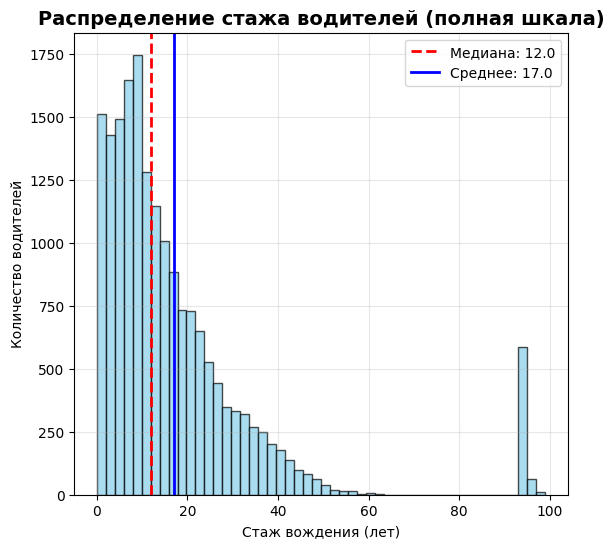

In [78]:
# статистики показывают, что у нас есть аномальные возрасты водителей, поэтому посмотрим водителей подробнее

drivers = dtp_participants[dtp_participants['role'] == 'Водитель'].copy()
print(f"Всего водителей в ДТП: {len(drivers)}")
print(f"Из них с указанным стажем: {drivers['driving_experience'].notna().sum()}")
print(f"Пропусков в данных о стаже: {drivers['driving_experience'].isna().sum()}")

print(drivers['driving_experience'].describe())

# гистограмма распределения стажа

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
n, bins, patches = plt.hist(drivers['driving_experience'].dropna(), bins=50, 
                             color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(drivers['driving_experience'].median(), color='red', linewidth=2, 
            linestyle='--', label=f'Медиана: {drivers["driving_experience"].median():.1f}')
plt.axvline(drivers['driving_experience'].mean(), color='blue', linewidth=2, 
            linestyle='-', label=f'Среднее: {drivers["driving_experience"].mean():.1f}')
plt.title('Распределение стажа водителей (полная шкала)', fontsize=14, fontweight='bold')
plt.xlabel('Стаж вождения (лет)')
plt.ylabel('Количество водителей')
plt.legend()
plt.grid(alpha=0.3)


C:\Users\Daria\AppData\Local\Temp\ipykernel_11324\3840611176.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box2 = plt.boxplot(data_to_plot, labels=top5_dtp, vert=True, patch_artist=True,


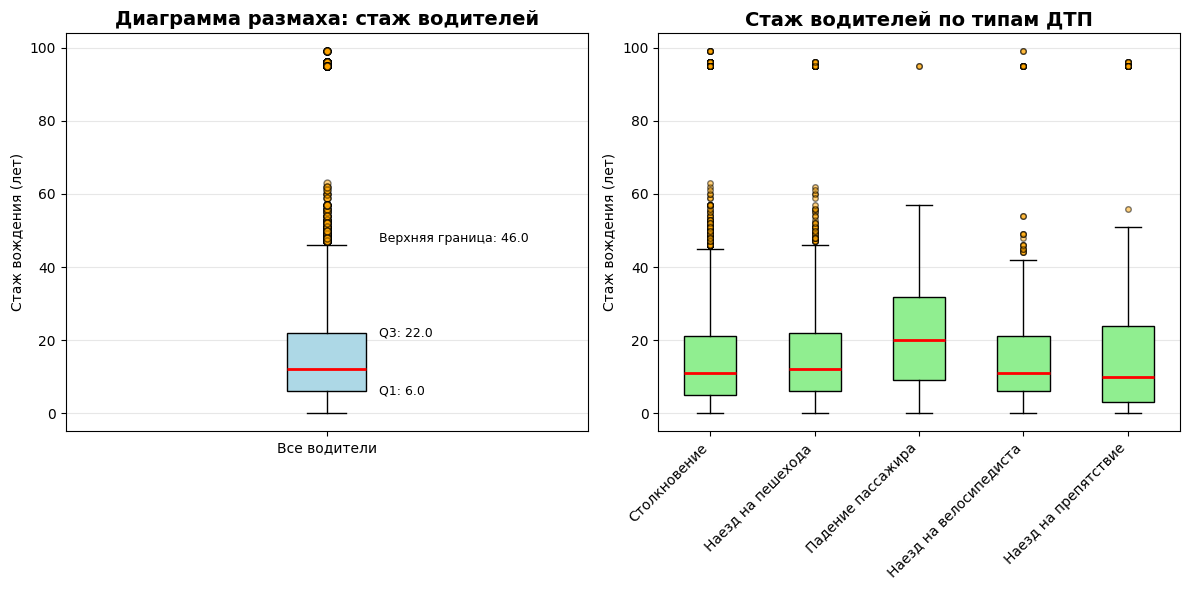

In [ ]:
# "ящик с усами" для всех водителей
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
box1 = plt.boxplot(drivers['driving_experience'].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'),
                   medianprops=dict(color='red', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='orange', markersize=5, alpha=0.5))
plt.title('Диаграмма размаха: стаж водителей', fontsize=14, fontweight='bold')
plt.ylabel('Стаж вождения (лет)')
plt.xticks([1], ['Все водители'])
plt.grid(axis='y', alpha=0.3)

q1 = drivers['driving_experience'].quantile(0.25)
q3 = drivers['driving_experience'].quantile(0.75)
iqr = q3 - q1
upper_whisker = q3 + 1.5 * iqr

plt.text(1.1, q1, f'Q1: {q1:.1f}', va='center', fontsize=9)
plt.text(1.1, q3, f'Q3: {q3:.1f}', va='center', fontsize=9)
plt.text(1.1, upper_whisker, f'Верхняя граница: {upper_whisker:.1f}', va='bottom', fontsize=9)

# диаграмма размаха по типам ДТП (топ-5)
plt.subplot(1, 2, 2)
top5_dtp = dtp_main['dtp_type'].value_counts().head(5).index.tolist()
drivers_top5 = drivers[drivers['dtp_type'].isin(top5_dtp)]

data_to_plot = [drivers_top5[drivers_top5['dtp_type'] == dtp]['driving_experience'].dropna() 
                for dtp in top5_dtp]

box2 = plt.boxplot(data_to_plot, labels=top5_dtp, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'),
                   medianprops=dict(color='red', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.5))
plt.title('Стаж водителей по типам ДТП', fontsize=14, fontweight='bold')
plt.ylabel('Стаж вождения (лет)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [80]:
# Тяжесть последствий для разных ролей в одинаковых типах ДТП
# В наездах на пешеходов - кто страдает сильнее: пешеход или водитель?
severity_by_role = dtp_participants[
    dtp_participants['dtp_type'] == 'Наезд на пешехода'
].groupby('role')['injury_severity'].value_counts(normalize=True)

severity_by_role

role                                                                                                                              injury_severity                                                                                                                                                                                           
Водитель                                                                                                                          Не пострадал                                                                                                                                                                                                  0.964719
                                                                                                                                                                                                                                                                                                                                  

In [81]:
# Распределение по полу
gender_distribution = dtp_participants['gender'].value_counts()
gender_percentages = (gender_distribution / len(dtp_participants) * 100).round(2)

gender_df = pd.DataFrame({
    'Пол': gender_distribution.index,
    'Количество': gender_distribution.values,
    'Процент': gender_percentages.values
})
print(gender_df.to_string(index=False))
print()


         Пол  Количество  Процент
     Мужской       19358    64.56
     Женский        9906    33.04
Не определен         660     2.20
                      60     0.20



C:\Users\Daria\AppData\Local\Temp\ipykernel_11324\1379487161.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


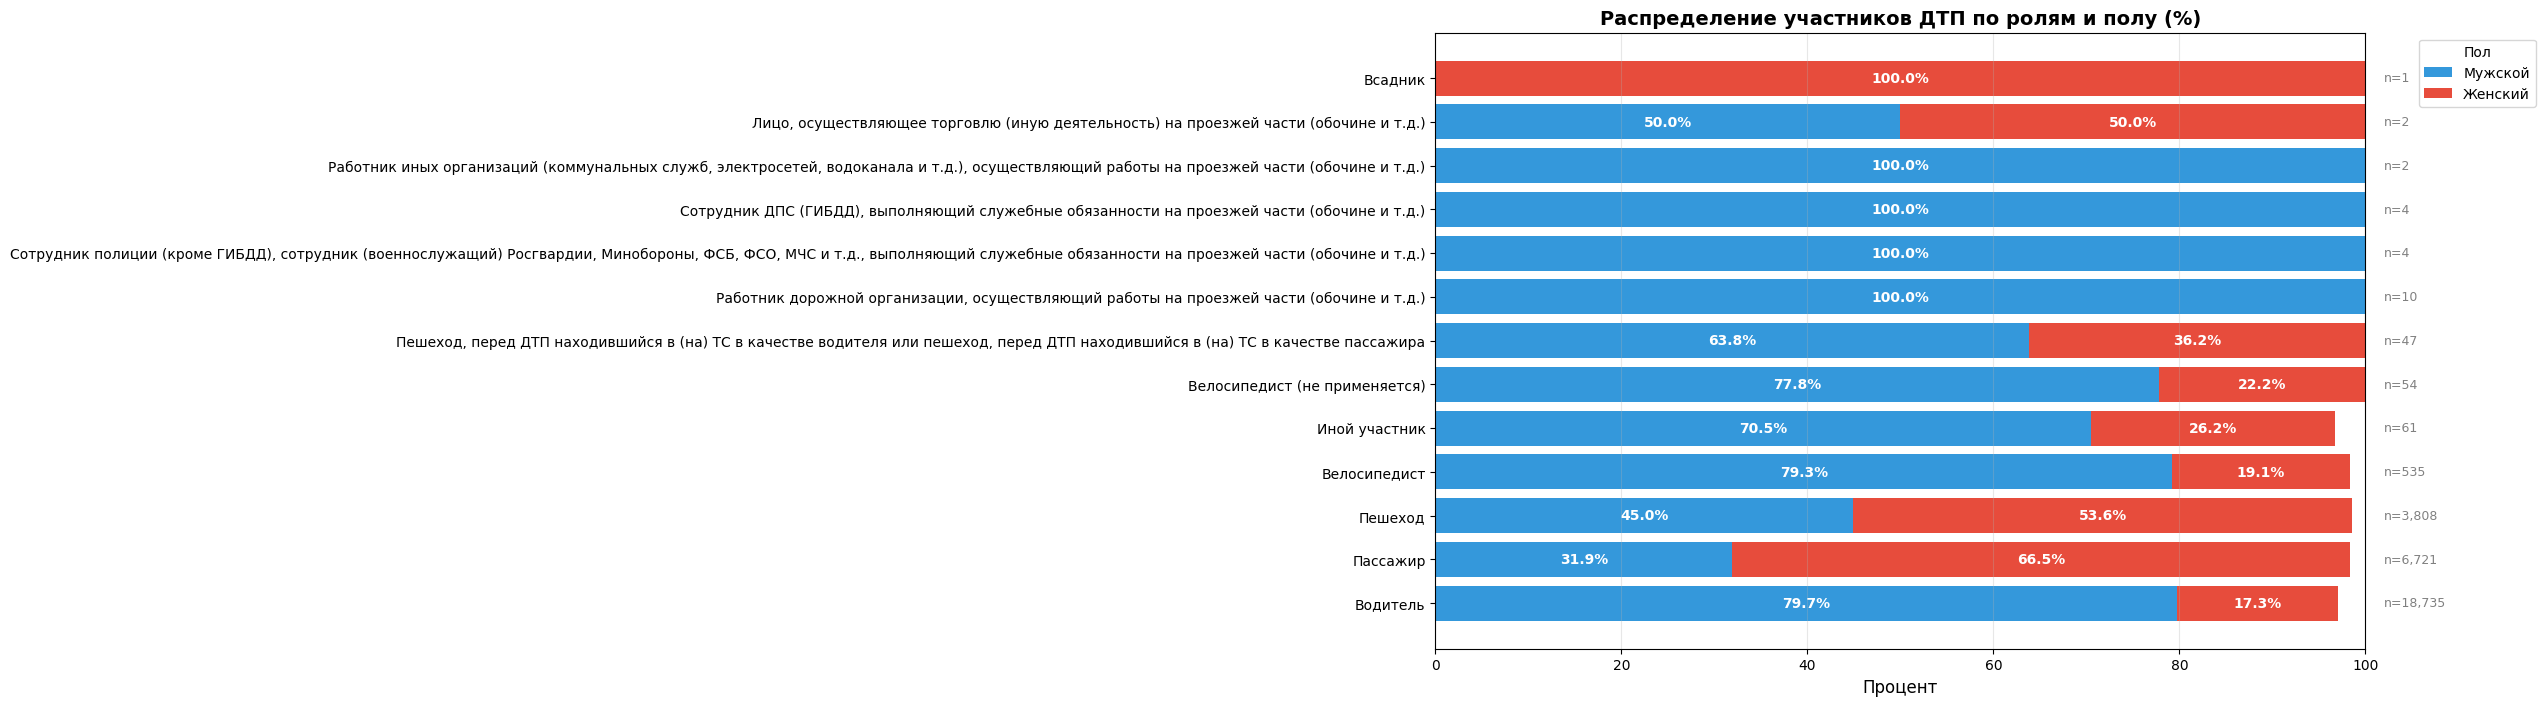

In [82]:
# график - пол по ролям
role_gender_pct = pd.crosstab(
    dtp_participants['role'], 
    dtp_participants['gender'],
    normalize='index'
) * 100

role_counts = dtp_participants['role'].value_counts()
role_gender_pct = role_gender_pct.loc[role_counts.index]

fig, ax = plt.subplots(figsize=(12, 8))

colors = {'Мужской':'#3498db', 'Женский': '#e74c3c'}

y_pos = np.arange(len(role_gender_pct.index))

left = np.zeros(len(role_gender_pct.index))

for gender in ['Мужской', 'Женский']:
    if gender in role_gender_pct.columns:
        values = role_gender_pct[gender].values
        bars = ax.barh(y_pos, values, left=left, label=gender, color=colors[gender])
        
        for i, (bar, val) in enumerate(zip(bars, values)):
            if val > 5:
                ax.text(left[i] + val/2, bar.get_y() + bar.get_height()/2, 
                       f'{val:.1f}%', ha='center', va='center', 
                       fontsize=10, fontweight='bold', color='white')
        
        left += values

ax.set_yticks(y_pos)
ax.set_yticklabels(role_gender_pct.index)
ax.set_xlabel('Процент', fontsize=12)
ax.set_title('Распределение участников ДТП по ролям и полу (%)', fontsize=14, fontweight='bold')
ax.legend(title='Пол', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.grid(axis='x', alpha=0.3)

for i, role in enumerate(role_gender_pct.index):  # количество участников
    count = role_counts[role]
    ax.text(102, i, f'n={count:,}', ha='left', va='center', 
            fontsize=9, color='gray')

plt.tight_layout()
plt.show()

In [83]:
# Тяжесть ДТП в разрезе пола участников 
# Создаем категории на основе injury_severity
# Погибшие - все, где есть слово "Скончался"
pogibshie = dtp_participants[dtp_participants['injury_severity'].str.contains('Скончался', na=False)]

# Раненые - все остальные, кроме "Не пострадал" и пустых
ranenye = dtp_participants[
    ~dtp_participants['injury_severity'].str.contains('Скончался', na=False) & 
    ~dtp_participants['injury_severity'].str.contains('Не пострадал', na=False)
]

print("Погибшие:")
pogibshie_count = len(pogibshie)
pogibshie_male = len(pogibshie[pogibshie['gender'] == 'Мужской'])
pogibshie_female = len(pogibshie[pogibshie['gender'] == 'Женский'])

print(f"  Всего погибших: {pogibshie_count} чел.")
print(f"  Мужчины: {pogibshie_male} чел. ({pogibshie_male/pogibshie_count*100:.1f}%)")
print(f"  Женщины: {pogibshie_female} чел. ({pogibshie_female/pogibshie_count*100:.1f}%)")
print()

print("Раненые:")
ranenye_count = len(ranenye)
ranenye_male = len(ranenye[ranenye['gender'] == 'Мужской'])
ranenye_female = len(ranenye[ranenye['gender'] == 'Женский'])

print(f"  Всего раненых: {ranenye_count:,} чел.")
print(f"  Мужчины: {ranenye_male:,} чел. ({ranenye_male/ranenye_count*100:.1f}%)")
print(f"  Женщины: {ranenye_female:,} чел. ({ranenye_female/ranenye_count*100:.1f}%)")


Погибшие:
  Всего погибших: 355 чел.
  Мужчины: 232 чел. (65.4%)
  Женщины: 123 чел. (34.6%)

Раненые:
  Всего раненых: 15,074 чел.
  Мужчины: 7,536 чел. (50.0%)
  Женщины: 7,211 чел. (47.8%)


In [84]:
# Погибшие по ролям и полу
fatal_by_role_gender = pd.crosstab(
    pogibshie['role'], 
    pogibshie['gender']
)

print("Погибшие по ролям и полу:")
print(fatal_by_role_gender)
print()

fatal_by_role_gender_pct = pd.crosstab(
    pogibshie['role'], 
    pogibshie['gender'],
    normalize='index'
) * 100

print("Распределение полов среди погибших в каждой роли (%):")
print(fatal_by_role_gender_pct.round(2))

Погибшие по ролям и полу:
gender                                                                                   Женский  \
role                                                                                               
Велосипедист                                                                                   1   
Велосипедист (не применяется)                                                                  0   
Водитель                                                                                       9   
Пассажир                                                                                      22   
Пешеход                                                                                       91   
Работник дорожной организации, осуществляющий работы на проезжей части (обочине и т.д.)        0   

gender                                                                                   Мужской  
role                                                                      

Промежуточные выводы:

Основные участники ДТП, ожидаемо, - водители (62.5%). Практически каждое пятое ДТП затрагивает пасажиров (22.4%). Третья группа участников - пешеходы (12.7%). Большинство водителей - мужчины (79.7%), большинство пешеходов и пассажиров - женщины (53.6% и 66.5%). 

В Тамбове доля пассажиров значительно выше (26.5% против ~19% в других городах), а пешеходов - ниже (9% против ~16%). Это может указывать на более высокую долю ДТП с участием общественного транспорта или иную структуру дорожного движения.

Столкновения и наезды на пешеходов совершают водители, имеющие стаж вождения более 10 лет. Водители, сбивающие пешеходов, имеют медианный стаж 12 лет, а участники столкновений - 11 лет. Это опровергает гипотезу, что наезды на пешеходов - проблема только неопытных водителей. При этом данные о водительском стаже содержат большое количество выбросов - аномальных значений 96, 99 лет, поэтому мы опираемся на медианные значения, а не средние. 

При наезде на пешеходов в 96.5% случаев водитель не пострадал, а пешеходы оказались травмированы в 99.6% случаев, в т.ч. в 4.5% пешеход погиб. 

Мужчины значительно чаще участвуют в ДТП (64.6% участников). Для мужчин риск погибнуть в ДТП выше, чем для женщин, даже с поправкой на частоту участия.

Среди погибших водителей подавляющее большинство мужчины (90%), а среди погибших пешеходов распределение почти равное (54% мужчин, 46% женщин). Это говорит о том, что женщины чаще гибнут как пешеходы и пассажиры, а мужчины - как водители, что соответствует общему соотношению полов в этих категориях. 



*1.4 Анализ транспортных средств*

In [86]:
# анализ ТС
kart_to_dtp_type = dict(zip(dtp_main['kart_id'], dtp_main['dtp_type']))
kart_to_fatalities = dict(zip(dtp_main['kart_id'], dtp_main['fatalities']))
kart_to_injured = dict(zip(dtp_main['kart_id'], dtp_main['injured']))

dtp_vehicles['city_name'] = dtp_vehicles['kart_id'].map(kart_to_city)
dtp_vehicles['dtp_type'] = dtp_vehicles['kart_id'].map(kart_to_dtp_type)
dtp_vehicles['fatalities'] = dtp_vehicles['kart_id'].map(kart_to_fatalities)
dtp_vehicles['injured'] = dtp_vehicles['kart_id'].map(kart_to_injured)
dtp_vehicles['has_fatalities'] = dtp_vehicles['fatalities'] > 0

In [87]:
# общая статистика
print(f"Всего ТС в ДТП: {len(dtp_vehicles):,}")
print(f"Уникальных ДТП с участием ТС: {dtp_vehicles['kart_id'].nunique():,}")
print(f"Среднее число ТС на одно ДТП: {len(dtp_vehicles)/dtp_vehicles['kart_id'].nunique():.2f}")

Всего ТС в ДТП: 19,767
Уникальных ДТП с участием ТС: 11,692
Среднее число ТС на одно ДТП: 1.69


In [88]:
# Распределение по статусу ТС
status_dist = dtp_vehicles['vehicle_status'].value_counts()
status_pct = (status_dist / len(dtp_vehicles) * 100).round(2)
status_df = pd.DataFrame({
    'Статус': status_dist.index,
    'Количество': status_dist.values,
    'Процент': status_pct.values
})
print(status_df.to_string(index=False))

                                        Статус  Количество  Процент
                         Осталось на месте ДТП       14571    73.71
                                           Нет        3839    19.42
      Скрылось и установлено в срок до 1 суток         341     1.73
                          Скрылось с места ДТП         335     1.69
                                     до 1 сут.         149     0.75
                                            Да         130     0.66
Скрылось и установлено в срок от 3 до 10 суток         114     0.58
  Скрылось и установлено в срок свыше 10 суток         112     0.57
 Скрылось и установлено в срок от 1 до 3 суток          87     0.44
                               от 1  до 3 сут.          39     0.20
                                 свыше 10 сут.          29     0.15
                               от 3 до 10 сут.          21     0.11


In [89]:
# Анализ типов ТС
category_dist = dtp_vehicles['vehicle_type'].value_counts()
category_pct = (category_dist / len(dtp_vehicles) * 100).round(2)

category_df = pd.DataFrame({
    'Категория ТС': category_dist.index,
    'Количество': category_dist.values,
    'Процент': category_pct.values
})
print(category_df.to_string(index=False))

                                                                                                          Категория ТС  Количество  Процент
                                                                                              В-класс (малый) до 3,9 м        7057    35.70
                                                                          С-класс (малый средний, компактный) до 4,3 м        4424    22.38
                                                                                            D-класс (средний) до 4,6 м        1924     9.73
                                                                                        А-класс (особо малый) до 3,5 м         819     4.14
                                                                                            Прочие легковые автомобили         793     4.01
                                                                                                            Велосипеды         533     2.70
                    

                                         Тип ТС  Количество  Процент
                       В-класс (малый) до 3,9 м        7057    35.70
   С-класс (малый средний, компактный) до 4,3 м        4424    22.38
                     D-класс (средний) до 4,6 м        1924     9.73
                 А-класс (особо малый) до 3,5 м         819     4.14
                     Прочие легковые автомобили         793     4.01
                                     Велосипеды         533     2.70
                Одноэтажные длиной от 8 до 12 м         505     2.55
                                      Мотоциклы         464     2.35
Е-класс (высший средний, бизнес-класс) до 4,9 м         451     2.28
                                        Фургоны         350     1.77


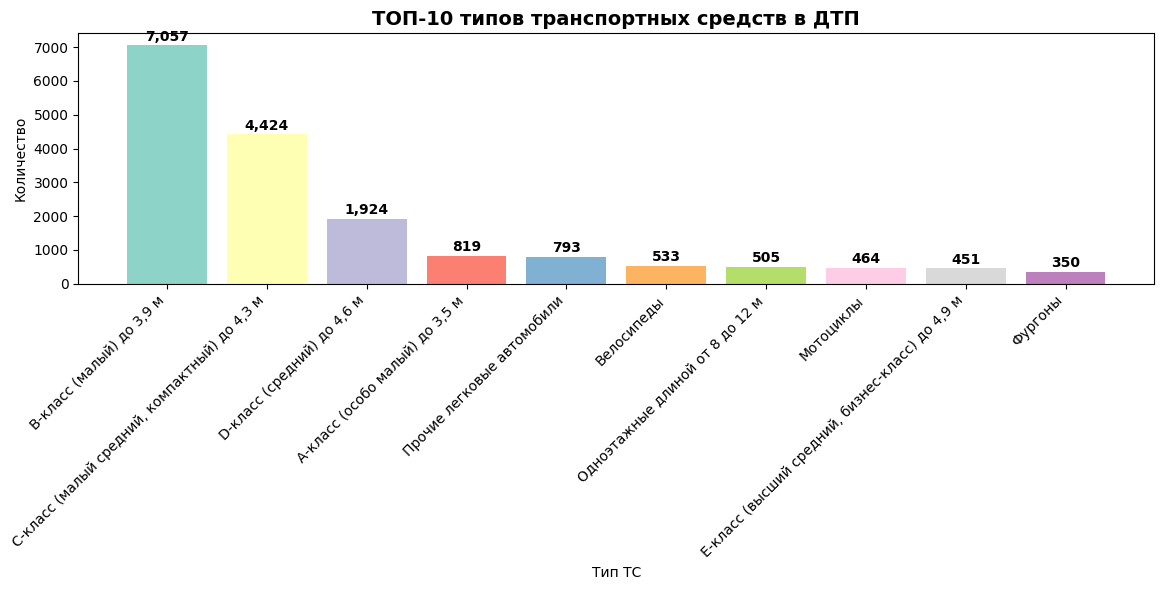

In [90]:
# топ-10 типов ДТП 
top10_vehicle_types = dtp_vehicles['vehicle_type'].value_counts().head(10)
top10_pct = (top10_vehicle_types / len(dtp_vehicles) * 100).round(2)

top10_df = pd.DataFrame({
    'Тип ТС': top10_vehicle_types.index,
    'Количество': top10_vehicle_types.values,
    'Процент': top10_pct.values
})
print(top10_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.Set3(range(len(top10_vehicle_types)))
bars = ax.bar(range(len(top10_vehicle_types)), top10_vehicle_types.values, color=colors)
ax.set_title('ТОП-10 типов транспортных средств в ДТП', fontsize=14, fontweight='bold')
ax.set_xlabel('Тип ТС')
ax.set_ylabel('Количество')
ax.set_xticks(range(len(top10_vehicle_types)))
ax.set_xticklabels(top10_vehicle_types.index, rotation=45, ha='right')

for bar, val in zip(bars, top10_vehicle_types.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
            f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Топ-5 типов ДТП:
  1. Столкновение
  2. Наезд на пешехода
  3. Падение пассажира
  4. Наезд на велосипедиста
  5. Наезд на препятствие

Распределение топ-5 типов ДТП для разных типов ТС (%):
dtp_type                                         Наезд на велосипедиста  \
vehicle_type_simple                                                       
В-класс (малый) до 3,9 м                                           3.93   
С-класс (малый средний, компактный) до 4,3 м                       2.78   
D-класс (средний) до 4,6 м                                         2.70   
А-класс (особо малый) до 3,5 м                                     4.68   
Прочие легковые автомобили                                         3.99   
Велосипеды                                                        98.48   
Одноэтажные длиной от 8 до 12 м                                    1.84   
Мотоциклы                                                          0.51   
Е-класс (высший средний, бизнес-класс) до 4,9 м            

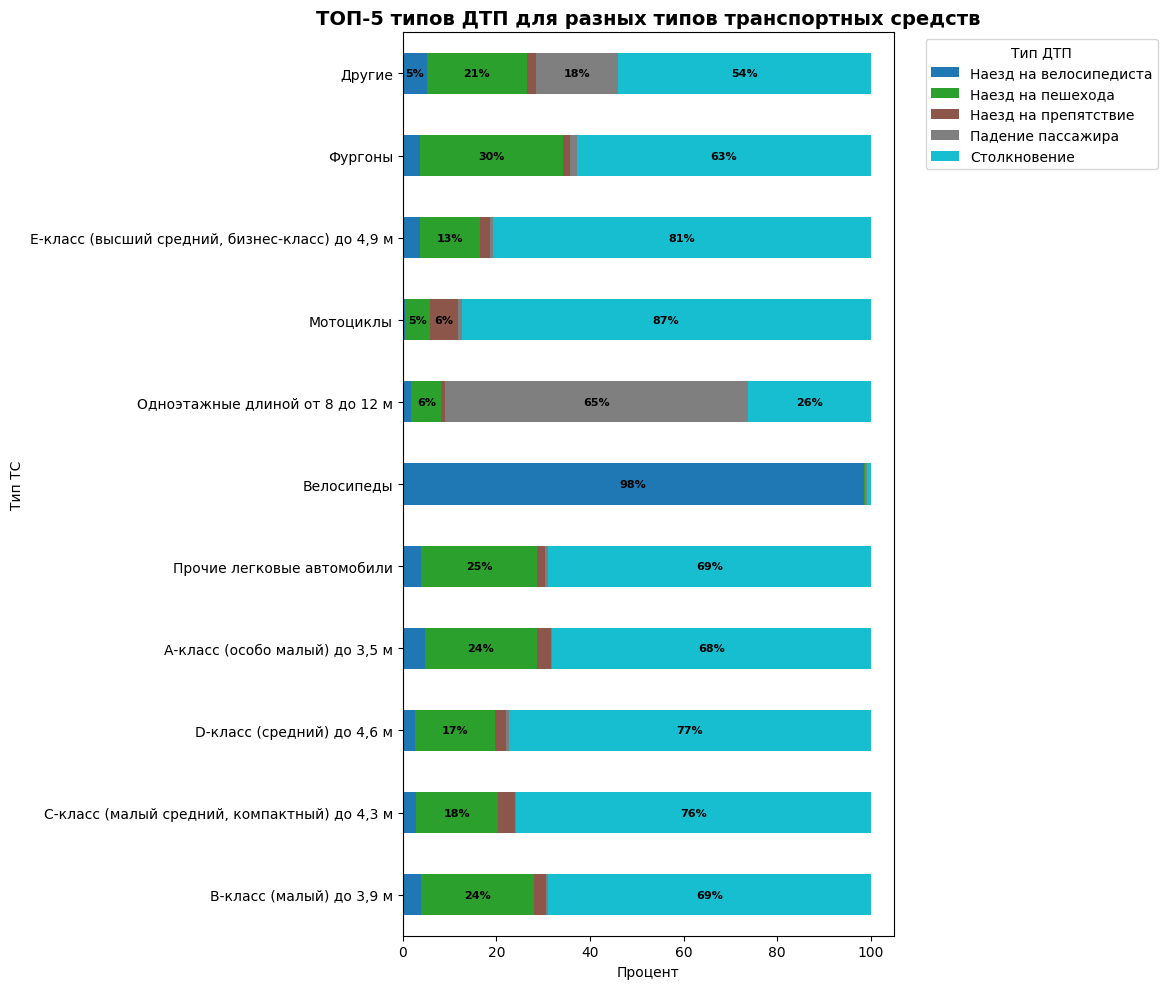

In [91]:
# Топ-5 типов ДТП
top5_dtp_types = dtp_main['dtp_type'].value_counts().head(5).index.tolist()
print("Топ-5 типов ДТП:")
for i, dtp in enumerate(top5_dtp_types, 1):
    print(f"  {i}. {dtp}")
print()

# топ-10 ТС, остальные объединяем в "Другие"
top10_list = top10_vehicle_types.index.tolist()
dtp_vehicles['vehicle_type_simple'] = dtp_vehicles['vehicle_type'].apply(
    lambda x: x if x in top10_list else 'Другие'
)

# топ-5 типов ДТП
vehicles_top5 = dtp_vehicles[dtp_vehicles['dtp_type'].isin(top5_dtp_types)]

vehicle_dtp = pd.crosstab(
    vehicles_top5['vehicle_type_simple'], 
    vehicles_top5['dtp_type'],
    normalize='index'
) * 100

type_order = top10_list + ['Другие']
vehicle_dtp = vehicle_dtp.reindex([t for t in type_order if t in vehicle_dtp.index])

print("Распределение топ-5 типов ДТП для разных типов ТС (%):")
print(vehicle_dtp.round(2))

fig, ax = plt.subplots(figsize=(12, 10))  

vehicle_dtp.plot(kind='barh', stacked=True, ax=ax, colormap='tab10')
ax.set_title('ТОП-5 типов ДТП для разных типов транспортных средств', fontsize=14, fontweight='bold')
ax.set_ylabel('Тип ТС')  
ax.set_xlabel('Процент')  
ax.legend(title='Тип ДТП', bbox_to_anchor=(1.05, 1))

for i, (cat, row) in enumerate(vehicle_dtp.iterrows()):
    left = 0  
    for j, (dtp, val) in enumerate(row.items()):
        if val > 5:
            ax.text(left + val/2, i, f'{val:.0f}%', 
                   ha='center', va='center', fontsize=8, fontweight='bold')
        left += val

plt.tight_layout()
plt.show()

In [92]:
# Распределение по техническому состоянию
tech_counts = dtp_vehicles['technical_condition'].value_counts()
tech_percentages = (tech_counts / len(dtp_vehicles) * 100).round(2)

tech_distribution = pd.DataFrame({
    'Техническое состояние': tech_counts.index,
    'Количество': tech_counts.values,
    'Процент': tech_percentages.values
})
print(tech_distribution.to_string(index=False))


                                                                                                                                                                                                                                                                                                                                    Техническое состояние  Количество  Процент
                                                                                                                                                                                                                                                                                                                    Технические неисправности отсутствуют       19256    97.41
                                                                                                                                                                                                                                                                          

     Марка  Количество  Процент
       ВАЗ        4545    30.97
   RENAULT        1280     8.72
   HYUNDAI         926     6.31
       KIA         851     5.80
VOLKSWAGEN         717     4.89
 CHEVROLET         705     4.80
    TOYOTA         681     4.64
      FORD         651     4.44
    NISSAN         490     3.34
     SKODA         480     3.27


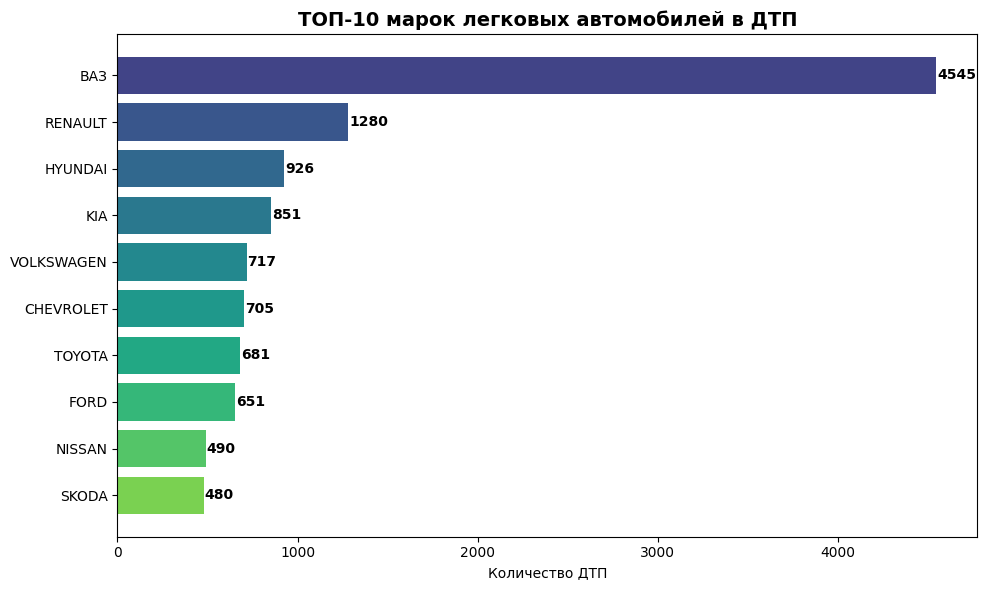

In [94]:
# марки автомобилей участников ДТП
car_types = [t for t in top10_list if 'легковой' in t.lower() or 'класс' in t.lower()]
cars = dtp_vehicles[dtp_vehicles['vehicle_type'].isin(car_types)]

make_dist = cars['make'].value_counts().head(10)
make_pct = (make_dist / len(cars) * 100).round(2)

make_df = pd.DataFrame({
    'Марка': make_dist.index,
    'Количество': make_dist.values,
    'Процент': make_pct.values
})
print(make_df.to_string(index=False))


fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(make_dist)))
bars = ax.barh(make_dist.index, make_dist.values, color=colors)
ax.set_title('ТОП-10 марок легковых автомобилей в ДТП', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество ДТП')
ax.invert_yaxis()

for bar, val in zip(bars, make_dist.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, 
            f'{val}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [96]:
# топ цветов транспортных средств
color_counts = dtp_vehicles['color'].value_counts()
color_percentages = (color_counts / len(dtp_vehicles) * 100).round(2)

top_colors = color_counts.head(20)

color_distribution = pd.DataFrame({
    'Цвет': top_colors.index,
    'Количество': top_colors.values,
    'Процент': color_percentages.head(20).values
})
print("Топ цветов автомобилей в ДТП:")
print(color_distribution.to_string(index=False))
print()

print(f"Всего уникальных цветов: {len(color_counts)}")
print(f"Всего автомобилей с указанным цветом: {dtp_vehicles['color'].count():,}")
print(f"Автомобилей без указания цвета: {dtp_vehicles['color'].isna().sum():,}")

Топ цветов автомобилей в ДТП:
        Цвет  Количество  Процент
       Белый        3611    18.27
  Иные цвета        3204    16.21
       Серый        3191    16.14
      Черный        3153    15.95
       Синий        1835     9.28
     Красный        1413     7.15
     Зеленый         983     4.97
  Коричневый         669     3.38
Многоцветный         470     2.38
      Желтый         294     1.49
   Оранжевый         186     0.94
  Фиолетовый         165     0.83
Не заполнено         104     0.53

Всего уникальных цветов: 13
Всего автомобилей с указанным цветом: 19,278
Автомобилей без указания цвета: 489


In [99]:
# анализ цвета ТС и тяжести ДТП
top_colors = color_counts.head(15)
top_list = top_colors.index.tolist()
vehicles_top_colors = dtp_vehicles[dtp_vehicles['color'].isin(top_list)]

color_severity = vehicles_top_colors.groupby('color').agg({
    'fatalities': ['sum', 'mean'],
    'injured': ['sum', 'mean'],
    'has_fatalities': 'mean',
    'kart_id': 'count'
}).round(3)

color_severity.columns = [
    'Всего погибших', 'Среднее кол-во погибших на ДТП',
    'Всего раненых', 'Среднее кол-во раненых на ДТП',
    'Доля смертельных ДТП', 'Количество ТС'
]

color_severity['% от всех ТС'] = (color_severity['Количество ТС'] / len(vehicles_top_colors) * 100).round(2)

color_severity_sorted = color_severity.sort_values('Доля смертельных ДТП', ascending=False)

print("Статистика по цветам (по убыванию доли смертельных ДТП):")
print(color_severity_sorted)

Статистика по цветам (по убыванию доли смертельных ДТП):
              Всего погибших  Среднее кол-во погибших на ДТП  Всего раненых  \
color                                                                         
Желтый                    16                           0.054            366   
Фиолетовый                 6                           0.036            200   
Оранжевый                  7                           0.038            244   
Красный                   46                           0.033           1818   
Синий                     56                           0.031           2316   
Черный                    95                           0.030           4036   
Серый                     89                           0.028           4125   
Зеленый                   24                           0.024           1288   
Белый                     87                           0.024           4744   
Коричневый                17                           0.025            91

Сводка по цветам:
        Цвет  Место по популярности  Количество  Доля смертельных ДТП (%)  Ср. погибших на 1000 ТС
       Белый                      1        3611                       2.2                    24.09
  Иные цвета                      2        3204                       1.9                    20.60
       Серый                      3        3191                       2.5                    27.89
      Черный                      4        3153                       2.7                    30.13
       Синий                      5        1835                       2.7                    30.52
     Красный                      6        1413                       3.0                    32.55
     Зеленый                      7         983                       2.2                    24.42
  Коричневый                      8         669                       2.2                    25.41
Многоцветный                      9         470                       2.1                  

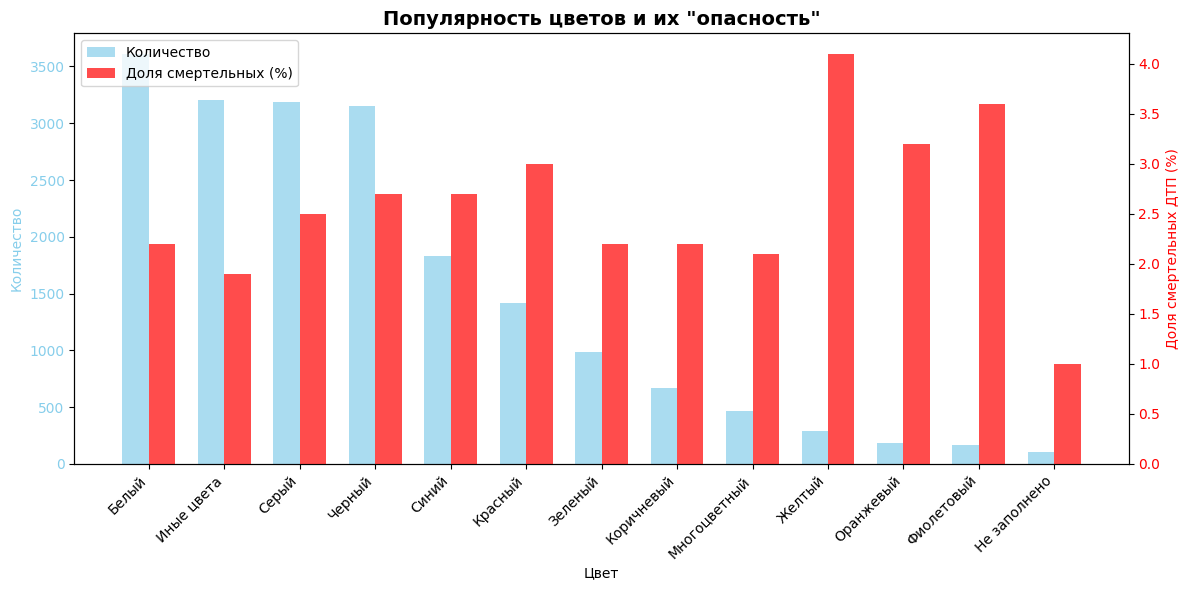

In [100]:
# Поиск корреляции между цветом и тяжестью ДТП
color_summary = pd.DataFrame({
    'Цвет': top_list,
    'Место по популярности': range(1, 14),
    'Количество': [color_counts[c] for c in top_list],
    'Доля смертельных ДТП (%)': [color_severity.loc[c, 'Доля смертельных ДТП'] * 100 for c in top_list],
    'Ср. погибших на 1000 ТС': [color_severity.loc[c, 'Всего погибших'] / color_severity.loc[c, 'Количество ТС'] * 1000 for c in top_list]
}).round(2)

print("Сводка по цветам:")
print(color_summary.to_string(index=False))


fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(top_list))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], color_summary['Количество'], width, 
                label='Количество', color='skyblue', alpha=0.7)
ax1.set_xlabel('Цвет')
ax1.set_ylabel('Количество', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(x)
ax1.set_xticklabels(top_list, rotation=45, ha='right')

ax2 = ax1.twinx()
bars2 = ax2.bar([i + width/2 for i in x], color_summary['Доля смертельных ДТП (%)'], width,
                label='Доля смертельных', color='red', alpha=0.7)
ax2.set_ylabel('Доля смертельных ДТП (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax1.set_title('Популярность цветов и их "опасность"', fontsize=14, fontweight='bold')
ax1.legend([bars1, bars2], ['Количество', 'Доля смертельных (%)'], loc='upper left')

plt.tight_layout()
plt.show()

In [103]:
# создаем целевую переменную - тяжесть ДТП
dtp_vehicles['severity_score'] = dtp_vehicles['fatalities'] * 10 + dtp_vehicles['injured']
dtp_vehicles['has_fatalities'] = dtp_vehicles['fatalities'] > 0

all_colors = dtp_vehicles['color'].dropna().unique().tolist()

color_counts = dtp_vehicles['color'].value_counts()

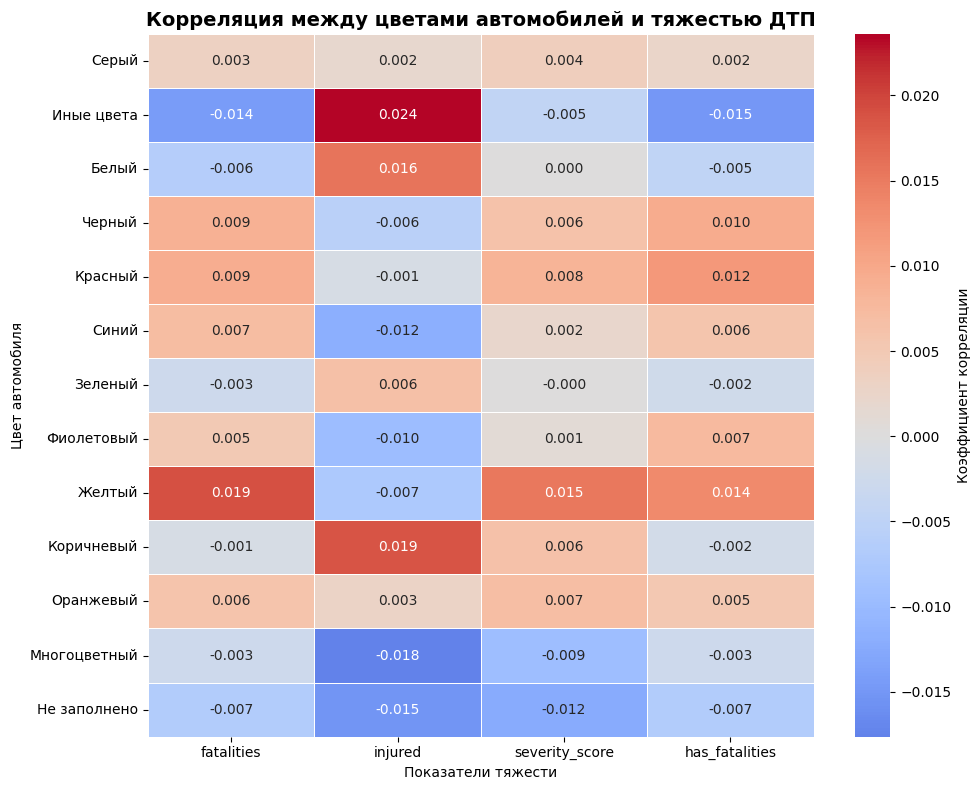

In [104]:
# корреляционная матрица
color_dummies = pd.get_dummies(dtp_vehicles['color'], prefix='', prefix_sep='')

corr_data = pd.concat([
    color_dummies,
    dtp_vehicles[['fatalities', 'injured', 'severity_score', 'has_fatalities']]
], axis=1)

corr_matrix = corr_data.corr()

color_severity_corr = corr_matrix.loc[
    all_colors,
    ['fatalities', 'injured', 'severity_score', 'has_fatalities']
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    color_severity_corr, 
    annot=True, 
    fmt='.3f', 
    cmap='coolwarm', 
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Коэффициент корреляции'}
)
plt.title('Корреляция между цветами автомобилей и тяжестью ДТП', fontsize=14, fontweight='bold')
plt.xlabel('Показатели тяжести')
plt.ylabel('Цвет автомобиля')
plt.tight_layout()
plt.show()

Промежуточные выводы:

За исследуемый период в ДТП участвовало 19 767 транспортных средств. Уникальных ДТП с участием ТС зафиксировано 11 692, таким образом, в среднем на одно ДТП приходится 1,69 автомобиля. Это подтверждает, что большинство аварий происходит с участием одного-двух транспортных средств.

Подавляющее большинство водителей (73.7%) остаются на месте происшествия. Еще 19.4% транспортных средств числятся в статусе "Нет" (вероятно, не повреждены или не участвовали непосредственно). Около 4% водителей скрываются с места ДТП, причем большинство из них устанавливаются в течение первых суток. Полностью нераскрытыми остаются лишь 0.66% случаев.

Легковые автомобили различных классов составляют основную массу участников ДТП - около 80%. Среди других участников выделяются велосипеды (2.7%), автобусы длиной 8-12 м (2.6%), мотоциклы (2.4%) и фургоны (1.8%).

Легковые автомобили всех классов демонстрируют схожую структуру: 68-77% составляют столкновения, еще 17-25% - наезды на пешеходов. Остальные виды ДТП встречаются значительно реже.
Мотоциклы попадают в столкновения в 87.4% случаев - это самый высокий показатель среди всех категорий ТС.
Автобусы длиной 8-12 м резко выделяются: 64.8% их ДТП связаны с падением пассажиров, что характерно для общественного транспорта. Столкновения составляют лишь 26.2%.
Велосипеды практически всегда (98.5%) участвуют в ДТП типа "наезд на велосипедиста", что логично вытекает из самой классификации.
Фургоны имеют смешанный профиль: 62.7% столкновений и 30.4% наездов на пешеходов.

Подавляющее большинство ТС (97.4%, или 19 256 единиц) на момент ДТП не имели технических неисправностей. Лишь 2.6% автомобилей имели какие-либо неполадки.

Среди легковых автомобилей безусловным лидером является отечественный ВАЗ - 31% (4545 ТС). Это означает, что практически каждый третий участник ДТП ездит на автомобиле этой марки.

Анализ цветов показывает преобладание практичных, немарких оттенков - белый, серый, черный - суммарно 50.3% всех ТС. Более высокая доля смертельных ДТП у желтых автомобилей - 4.1%, но это скорее объясняется малым размером выборки, что подтверждает корреляционная матрица. Все коэффициенты корреляции между цветом и показателями тяжести находятся в диапазоне от -0,02 до 0,02, что свидетельствует об отсутствии статистически значимой связи. Цвет автомобиля не влияет на тяжесть ДТП.

*Часть 2. Анализ влияния погодных условий на ДТП*

*2.2 Анализ погодных условий в момент ДТП*

Погодное условие | Количество | %
----------------------------------------
Ясно            |   5822 |  49.8%
Пасмурно        |   4815 |  41.2%
Дождь           |    658 |   5.6%
Снегопад        |    370 |   3.2%
Туман           |     22 |   0.2%
Метель          |      5 |   0.0%



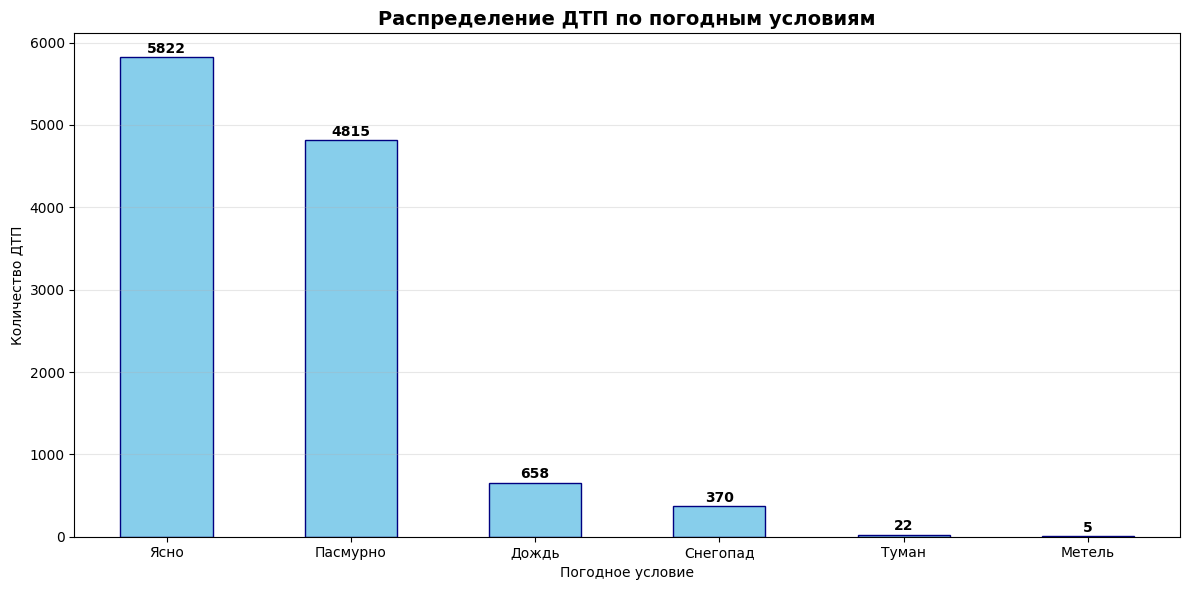

In [109]:
# распределение ДТП по погодным условиям

# функция для извлечения основного погодного условия
def get_weather(weather_list):
    if not isinstance(weather_list, list) or len(weather_list) == 0:
        return 'Не указано'
    if 'Дождь' in weather_list:
        return 'Дождь'
    if 'Снегопад' in weather_list:
        return 'Снегопад'
    if 'Метель' in weather_list:
        return 'Метель'
    if 'Туман' in weather_list:
        return 'Туман'
    if 'Пасмурно' in weather_list:
        return 'Пасмурно'
    if 'Ясно' in weather_list:
        return 'Ясно'
    return weather_list[0]

dtp_with_weather['weather_main'] = dtp_with_weather['weather_conditions'].apply(get_weather)

weather_dist = dtp_with_weather['weather_main'].value_counts()
weather_pct = (weather_dist / len(dtp_with_weather) * 100).round(2)

print("Погодное условие | Количество | %")
print("-" * 40)
for weather, count in weather_dist.items():
    print(f"{weather:<15} | {count:>6} | {weather_pct[weather]:>5.1f}%")
print()

plt.figure(figsize=(12, 6))
weather_dist.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='navy')
plt.title('Распределение ДТП по погодным условиям', fontsize=14, fontweight='bold')
plt.xlabel('Погодное условие')
plt.ylabel('Количество ДТП')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for i, (weather, count) in enumerate(weather_dist.sort_values(ascending=False).items()):
    plt.text(i, count + 20, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Статистика по погодным условиям (отсортировано по смертности):
              Всего погибших  Ср. погибших на ДТП  Всего раненых  \
weather_main                                                       
Дождь                     22                0.033            799   
Пасмурно                 159                0.033           5870   
Снегопад                  12                0.032            478   
Ясно                     162                0.028           7156   
Метель                     0                0.000              7   
Туман                      0                0.000             28   

              Ср. раненых на ДТП  Количество ДТП  % от всех ДТП  \
weather_main                                                      
Дождь                      1.214             658           5.63   
Пасмурно                   1.219            4815          41.18   
Снегопад                   1.292             370           3.16   
Ясно                       1.229            5822         

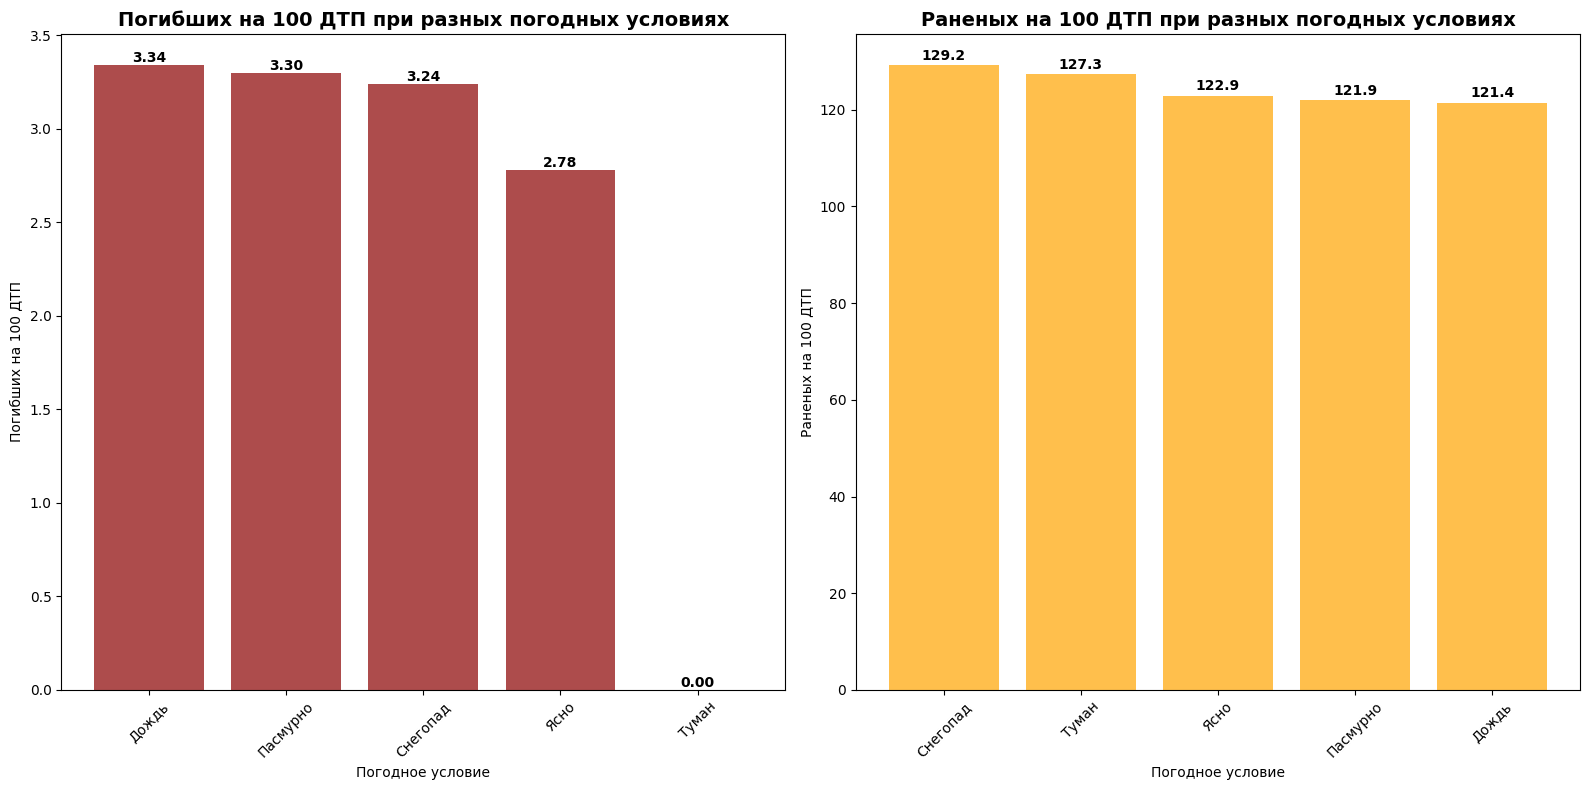

In [110]:
# Группировка по погодным условиям
weather_severity = dtp_with_weather.groupby('weather_main').agg({
    'fatalities': ['sum', 'mean'],
    'injured': ['sum', 'mean'],
    'kart_id': 'count'
}).round(3)

weather_severity.columns = ['Всего погибших', 'Ср. погибших на ДТП', 
                            'Всего раненых', 'Ср. раненых на ДТП', 
                            'Количество ДТП']

weather_severity['% от всех ДТП'] = (weather_severity['Количество ДТП'] / len(dtp_with_weather) * 100).round(2)
weather_severity['Погибших на 100 ДТП'] = (weather_severity['Всего погибших'] / weather_severity['Количество ДТП'] * 100).round(2)
weather_severity['Раненых на 100 ДТП'] = (weather_severity['Всего раненых'] / weather_severity['Количество ДТП'] * 100).round(2)

print("Статистика по погодным условиям (отсортировано по смертности):")
print(weather_severity.sort_values('Погибших на 100 ДТП', ascending=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Погибших на 100 ДТП (только с достаточным количеством ДТП)
weather_with_enough = weather_severity[weather_severity['Количество ДТП'] >= 10]
fatal_rate = weather_with_enough['Погибших на 100 ДТП'].sort_values(ascending=False)

bars1 = axes[0].bar(fatal_rate.index, fatal_rate.values, color='darkred', alpha=0.7)
axes[0].set_title('Погибших на 100 ДТП при разных погодных условиях', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Погодное условие')
axes[0].set_ylabel('Погибших на 100 ДТП')
axes[0].tick_params(axis='x', rotation=45)

for bar, val in zip(bars1, fatal_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

# Раненых на 100 ДТП
injured_rate = weather_with_enough['Раненых на 100 ДТП'].sort_values(ascending=False)

bars2 = axes[1].bar(injured_rate.index, injured_rate.values, color='orange', alpha=0.7)
axes[1].set_title('Раненых на 100 ДТП при разных погодных условиях', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Погодное условие')
axes[1].set_ylabel('Раненых на 100 ДТП')
axes[1].tick_params(axis='x', rotation=45)

for bar, val in zip(bars2, injured_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [111]:
# Анализ сочетаний погодных условий
dtp_with_weather['conditions_count'] = dtp_with_weather['weather_conditions'].apply(len)

print(f"ДТП с одним погодным условием: {(dtp_with_weather['conditions_count'] == 1).sum()} ({(dtp_with_weather['conditions_count'] == 1).sum()/len(dtp_with_weather)*100:.1f}%)")
print(f"ДТП с двумя погодными условиями: {(dtp_with_weather['conditions_count'] == 2).sum()} ({(dtp_with_weather['conditions_count'] == 2).sum()/len(dtp_with_weather)*100:.1f}%)")
print(f"ДТП с тремя и более условиями: {(dtp_with_weather['conditions_count'] >= 3).sum()} ({(dtp_with_weather['conditions_count'] >= 3).sum()/len(dtp_with_weather)*100:.1f}%)")
print()

# Самые частые комбинации
from collections import Counter
combinations = [str(sorted(lst)) for lst in dtp_with_weather['weather_conditions'] if len(lst) > 1]
comb_counter = Counter(combinations)

print("Топ-5 комбинаций погодных условий:")
for comb, count in comb_counter.most_common(5):
    print(f"  {comb}: {count} ДТП")
print()

# Сравнение тяжести ДТП для одиночных и комбинированных условий
single_cond = dtp_with_weather[dtp_with_weather['conditions_count'] == 1]
multi_cond = dtp_with_weather[dtp_with_weather['conditions_count'] >= 2]

print("Сравнение одиночных и комбинированных условий:")
print(f"  Одиночные условия: {single_cond['fatalities'].sum()} погибших, {single_cond['fatalities'].mean()*100:.2f} на 100 ДТП")
print(f"  Комбинированные: {multi_cond['fatalities'].sum()} погибших, {multi_cond['fatalities'].mean()*100:.2f} на 100 ДТП")

ДТП с одним погодным условием: 11301 (96.7%)
ДТП с двумя погодными условиями: 391 (3.3%)
ДТП с тремя и более условиями: 0 (0.0%)

Топ-5 комбинаций погодных условий:
  ['Дождь', 'Пасмурно']: 217 ДТП
  ['Пасмурно', 'Снегопад']: 76 ДТП
  ['Температура выше +30С', 'Ясно']: 72 ДТП
  ['Пасмурно', 'Туман']: 12 ДТП
  ['Дождь', 'Снегопад']: 4 ДТП

Сравнение одиночных и комбинированных условий:
  Одиночные условия: 347 погибших, 3.07 на 100 ДТП
  Комбинированные: 8 погибших, 2.05 на 100 ДТП


Распределение ДТП по температуре:
temp_cat
Тепло 10...20°C       3444
Прохладно 0...10°C    3425
Мороз -10...0°C       2352
Жарко 20...30°C       1910
Мороз -20...-10°C      400
Жара > 30°C             74
Нет данных              50
Мороз < -20°C           37
Name: count, dtype: int64

Проценты:
temp_cat
Тепло 10...20°C       29.46
Прохладно 0...10°C    29.29
Мороз -10...0°C       20.12
Жарко 20...30°C       16.34
Мороз -20...-10°C      3.42
Жара > 30°C            0.63
Нет данных             0.43
Мороз < -20°C          0.32
Name: count, dtype: float64

Погибшие при разной температуре (на 100 ДТП):
                    count  sum  fatal_per_100
temp_cat                                     
Прохладно 0...10°C   3425  141           4.12
Мороз -20...-10°C     400   14           3.50
Мороз < -20°C          37    1           2.70
Тепло 10...20°C      3444   90           2.61
Мороз -10...0°C      2352   60           2.55
Жарко 20...30°C      1910   48           2.51
Жара > 30°C            74   

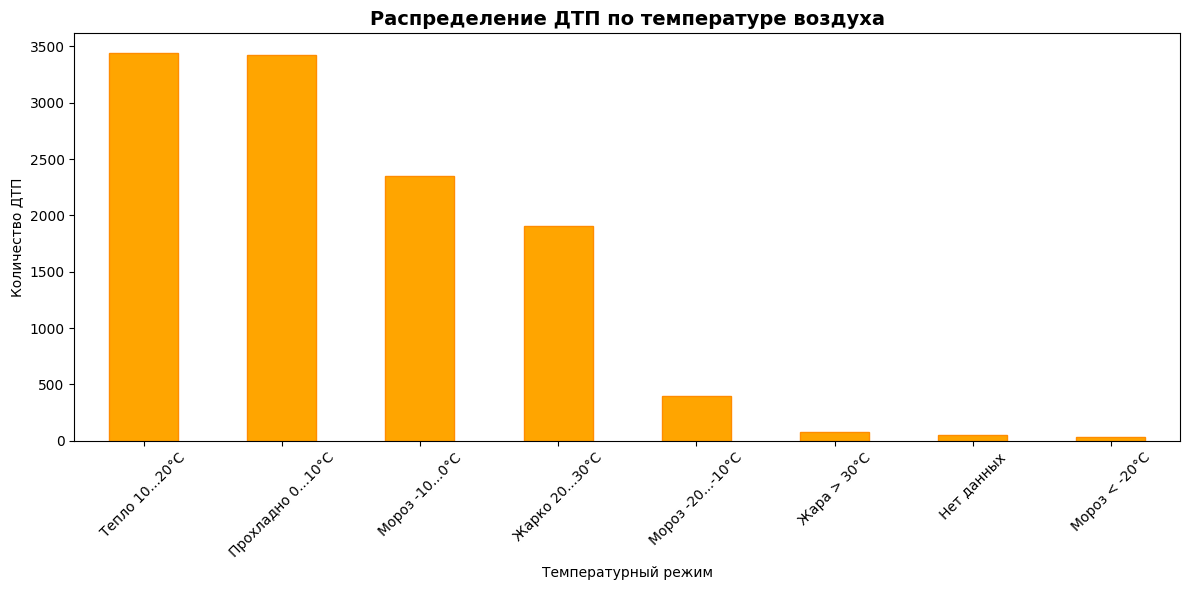

In [116]:
# анализ температуры

def temp_category(temp):
    if pd.isna(temp):
        return 'Нет данных'
    if temp < -20:
        return 'Мороз < -20°C'
    if temp < -10:
        return 'Мороз -20...-10°C'
    if temp < 0:
        return 'Мороз -10...0°C'
    if temp < 10:
        return 'Прохладно 0...10°C'
    if temp < 20:
        return 'Тепло 10...20°C'
    if temp < 30:
        return 'Жарко 20...30°C'
    return 'Жара > 30°C'

dtp_with_weather['temp_cat'] = dtp_with_weather['temperature_2m'].apply(temp_category)

temp_dist = dtp_with_weather['temp_cat'].value_counts()
print("Распределение ДТП по температуре:")
print(temp_dist)
print(f"\nПроценты:\n{(temp_dist / len(dtp_with_weather) * 100).round(2)}")
print()

temp_fatal = dtp_with_weather.groupby('temp_cat')['fatalities'].agg(['sum', 'mean', 'count'])
temp_fatal['fatal_per_100'] = (temp_fatal['sum'] / temp_fatal['count'] * 100).round(2)
print("Погибшие при разной температуре (на 100 ДТП):")
print(temp_fatal[['count', 'sum', 'fatal_per_100']].sort_values('fatal_per_100', ascending=False))
print()

plt.figure(figsize=(12, 6))
temp_dist.sort_values(ascending=False).plot(kind='bar', color='orange', edgecolor='darkorange')
plt.title('Распределение ДТП по температуре воздуха', fontsize=14, fontweight='bold')
plt.xlabel('Температурный режим')
plt.ylabel('Количество ДТП')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Коэффициенты корреляции Пирсона:
                temperature_2m  temp_cat_num  fatalities  injured  has_precip
temperature_2m           1.000         0.964      -0.018   -0.004      -0.089
temp_cat_num             0.964         1.000      -0.013   -0.007      -0.083
fatalities              -0.018        -0.013       1.000   -0.142      -0.010
injured                 -0.004        -0.007      -0.142    1.000      -0.003
has_precip              -0.089        -0.083      -0.010   -0.003       1.000



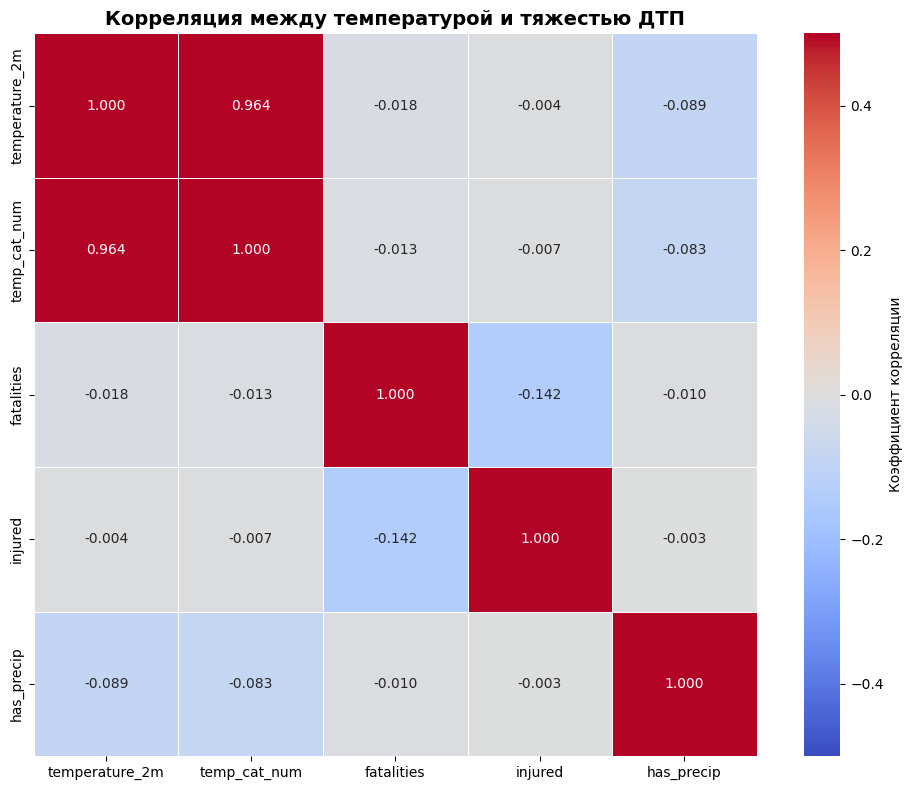

In [118]:
# корреляционная матрица: температура воздуха и ДТП

dtp_corr = dtp_with_weather.copy()

# бинарные переменные для осадков
dtp_corr['has_rain'] = (dtp_corr['rain'] > 0).astype(int)
dtp_corr['has_snow'] = (dtp_corr['snowfall'] > 0).astype(int)
dtp_corr['has_precip'] = ((dtp_corr['rain'] > 0) | (dtp_corr['snowfall'] > 0)).astype(int)

# категориальные переменные в числовые для корреляции
temp_order = {
    'Мороз < -20°C': 1,
    'Мороз -20...-10°C': 2,
    'Мороз -10...0°C': 3,
    'Прохладно 0...10°C': 4,
    'Тепло 10...20°C': 5,
    'Жарко 20...30°C': 6,
    'Жара > 30°C': 7,
    'Нет данных': np.nan
}
dtp_corr['temp_cat_num'] = dtp_corr['temp_cat'].map(temp_order)

precip_order = {'Без осадков': 0, 'Дождь': 1, 'Снег': 2}
dtp_corr['precip_num'] = dtp_corr['precip'].map(precip_order)

temp_corr_columns = [
    'temperature_2m', 'temp_cat_num',
    'fatalities', 'injured', 'has_precip'
]

temp_corr_matrix = dtp_corr[temp_corr_columns].corr(method='pearson').round(3)

print("Коэффициенты корреляции Пирсона:")
print(temp_corr_matrix)
print()

plt.figure(figsize=(10, 8))
sns.heatmap(temp_corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-0.5, vmax=0.5,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Корреляция между температурой и тяжестью ДТП', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [115]:
# анализ осадков

def precip_type(row):
    if row['snowfall'] > 0:
        return 'Снег'
    if row['rain'] > 0:
        return 'Дождь'
    return 'Без осадков'

dtp_with_weather['precip'] = dtp_with_weather.apply(precip_type, axis=1)

precip_dist = dtp_with_weather['precip'].value_counts()
print("Распределение ДТП по осадкам:")
print(precip_dist)
print(f"\nПроценты:\n{(precip_dist / len(dtp_with_weather) * 100).round(2)}")
print()

# Тяжесть ДТП при разных осадках
precip_fatal = dtp_with_weather.groupby('precip')['fatalities'].agg(['sum', 'mean', 'count'])
precip_fatal['fatal_per_100'] = (precip_fatal['sum'] / precip_fatal['count'] * 100).round(2)
print("Погибшие при разных осадках (на 100 ДТП):")
print(precip_fatal[['count', 'sum', 'fatal_per_100']].sort_values('fatal_per_100', ascending=False))
print()

# Интенсивность осадков
print(f"Средний дождь при ДТП: {dtp_with_weather[dtp_with_weather['rain'] > 0]['rain'].mean():.3f} мм")
print(f"Средний снегопад при ДТП: {dtp_with_weather[dtp_with_weather['snowfall'] > 0]['snowfall'].mean():.3f} мм")

Распределение ДТП по осадкам:
precip
Без осадков    9234
Дождь          1623
Снег            835
Name: count, dtype: int64

Проценты:
precip
Без осадков    78.98
Дождь          13.88
Снег            7.14
Name: count, dtype: float64

Погибшие при разных осадках (на 100 ДТП):
             count  sum  fatal_per_100
precip                                
Без осадков   9234  289           3.13
Дождь         1623   50           3.08
Снег           835   16           1.92

Средний дождь при ДТП: 0.456 мм
Средний снегопад при ДТП: 0.218 мм


Коэффициенты корреляции Пирсона:
             rain  snowfall  has_rain  has_snow  has_precip  fatalities  \
rain        1.000    -0.010     0.563    -0.034       0.454      -0.008   
snowfall   -0.010     1.000     0.009     0.682       0.367      -0.014   
has_rain    0.563     0.009     1.000    -0.018       0.807      -0.001   
has_snow   -0.034     0.682    -0.018     1.000       0.538      -0.017   
has_precip  0.454     0.367     0.807     0.538       1.000      -0.010   
fatalities -0.008    -0.014    -0.001    -0.017      -0.010       1.000   
injured     0.002     0.001    -0.006     0.008      -0.003      -0.142   

            injured  
rain          0.002  
snowfall      0.001  
has_rain     -0.006  
has_snow      0.008  
has_precip   -0.003  
fatalities   -0.142  
injured       1.000  



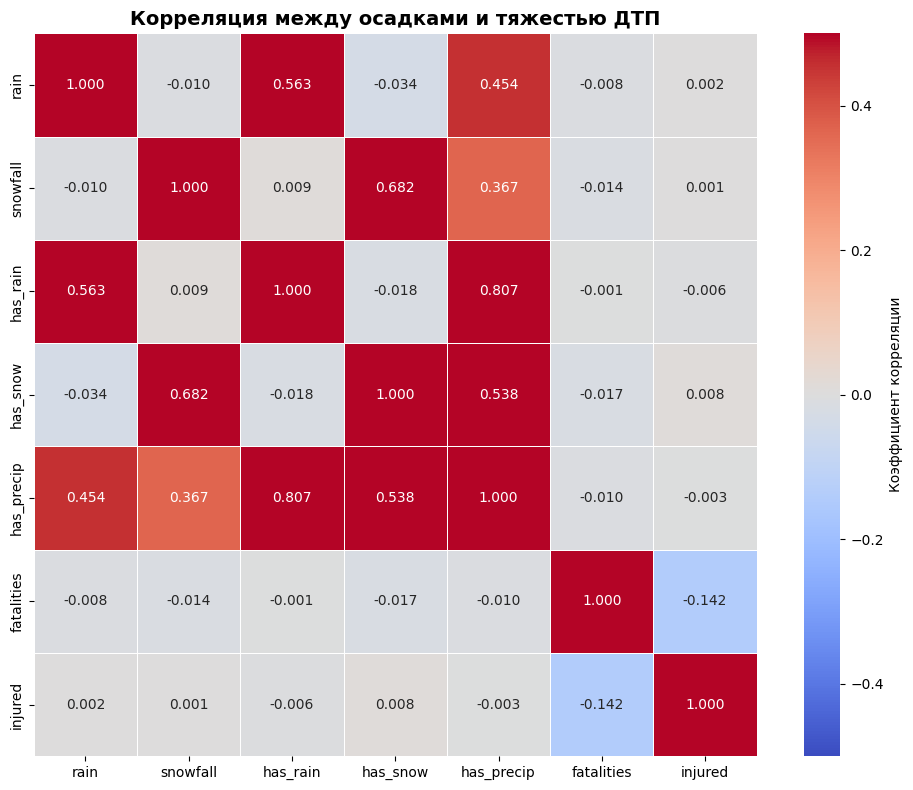

In [119]:
# корреляционная матрица: осадки и ДТП

precip_corr_columns = [
    'rain', 'snowfall', 'has_rain', 'has_snow', 'has_precip',
    'fatalities', 'injured'
]

precip_corr_matrix = dtp_corr[precip_corr_columns].corr(method='pearson').round(3)

print("Коэффициенты корреляции Пирсона:")
print(precip_corr_matrix)
print()

plt.figure(figsize=(10, 8))
sns.heatmap(precip_corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-0.5, vmax=0.5,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Корреляция между осадками и тяжестью ДТП', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Топ-8 состояний покрытия:
Покрытие                     ДТП      % Погибшие/100  Раненые/100
Сухое                       6914  59.13        2.88       122.29
Мокрое                      3064  26.21        3.46       122.36
Обработанное противоголол   1098   9.39        3.19        125.5
Заснеженное                  361   3.09        2.49       119.39
Гололедица                   133   1.14        2.26       130.08
Со снежным накатом            71   0.61        2.82       114.08
Загрязненное                  35    0.3        2.86       125.71
Свежеуложенная поверхност     12    0.1         0.0       191.67



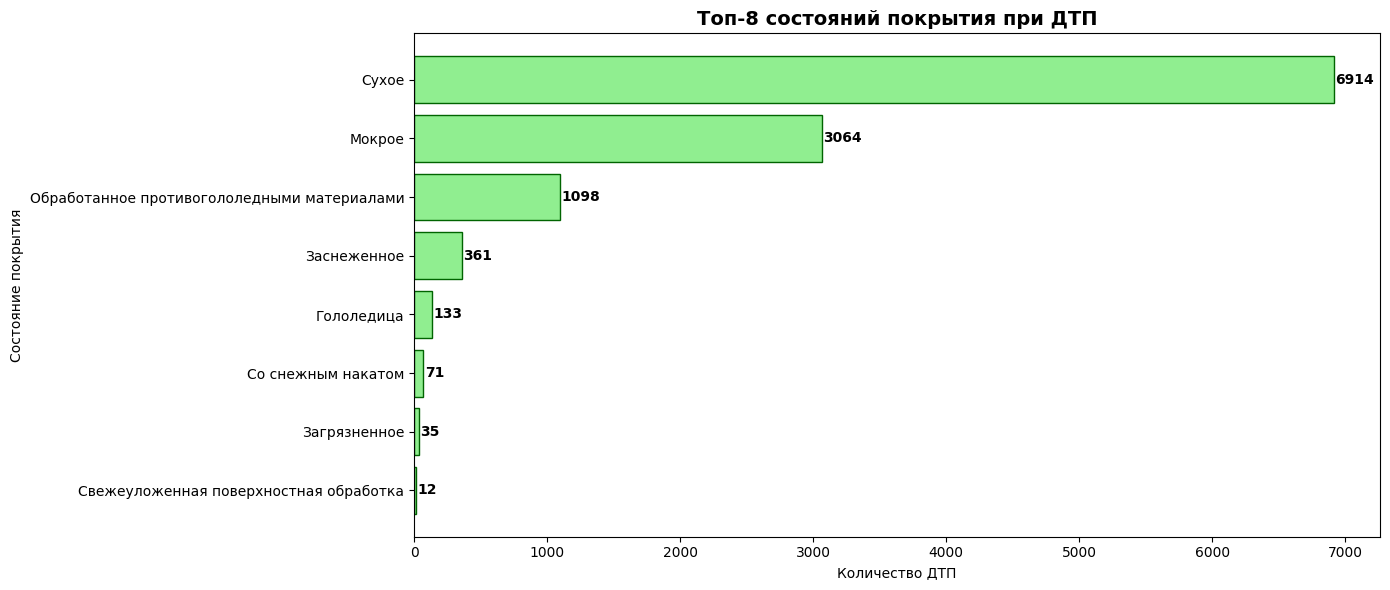

In [114]:
# анализ дорожных условий

surface_stats = dtp_with_weather.groupby('road_surface').agg({
    'kart_id': 'count',
    'fatalities': ['sum', 'mean'],
    'injured': ['sum', 'mean']
}).round(2)

surface_stats.columns = ['dtp_count', 'fatal_sum', 'fatal_mean', 'injured_sum', 'injured_mean']

surface_stats['percent'] = (surface_stats['dtp_count'] / len(dtp_with_weather) * 100).round(2)
surface_stats['fatal_per_100'] = (surface_stats['fatal_sum'] / surface_stats['dtp_count'] * 100).round(2)
surface_stats['injured_per_100'] = (surface_stats['injured_sum'] / surface_stats['dtp_count'] * 100).round(2)

surface_top8 = surface_stats.sort_values('dtp_count', ascending=False).head(8)

print("\nТоп-8 состояний покрытия:")
print(f"{'Покрытие':<25} {'ДТП':>6} {'%':>6} {'Погибшие/100':>12} {'Раненые/100':>12}")

for surface, row in surface_top8.iterrows():
    print(f"{surface[:25]:<25} {int(row['dtp_count']):>6} {row['percent']:>6} {row['fatal_per_100']:>11} {row['injured_per_100']:>12}")
print()

plt.figure(figsize=(14, 6))

plot_data = surface_top8.sort_values('dtp_count', ascending=True)

bars = plt.barh(plot_data.index, plot_data['dtp_count'], color='lightgreen', edgecolor='darkgreen')
plt.title('Топ-8 состояний покрытия при ДТП', fontsize=14, fontweight='bold')
plt.xlabel('Количество ДТП')
plt.ylabel('Состояние покрытия')

for bar, count in zip(bars, plot_data['dtp_count']):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
             f'{int(count)}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()
print()


Распределение ДТП по условиям освещения:
Освещение                                        ДТП      % Погибшие/100  Раненые/100
Светлое время суток                             7748  66.27        1.92        120.9
В темное время суток, освещение включено        3385  28.95        4.93       126.23
Сумерки                                          350   2.99         2.0       126.29
В темное время суток, освещение отсутствует      122   1.04       18.85       118.85
В темное время суток, освещение не включено       86   0.74       10.47       127.91
Не установлено                                     1   0.01         0.0        100.0



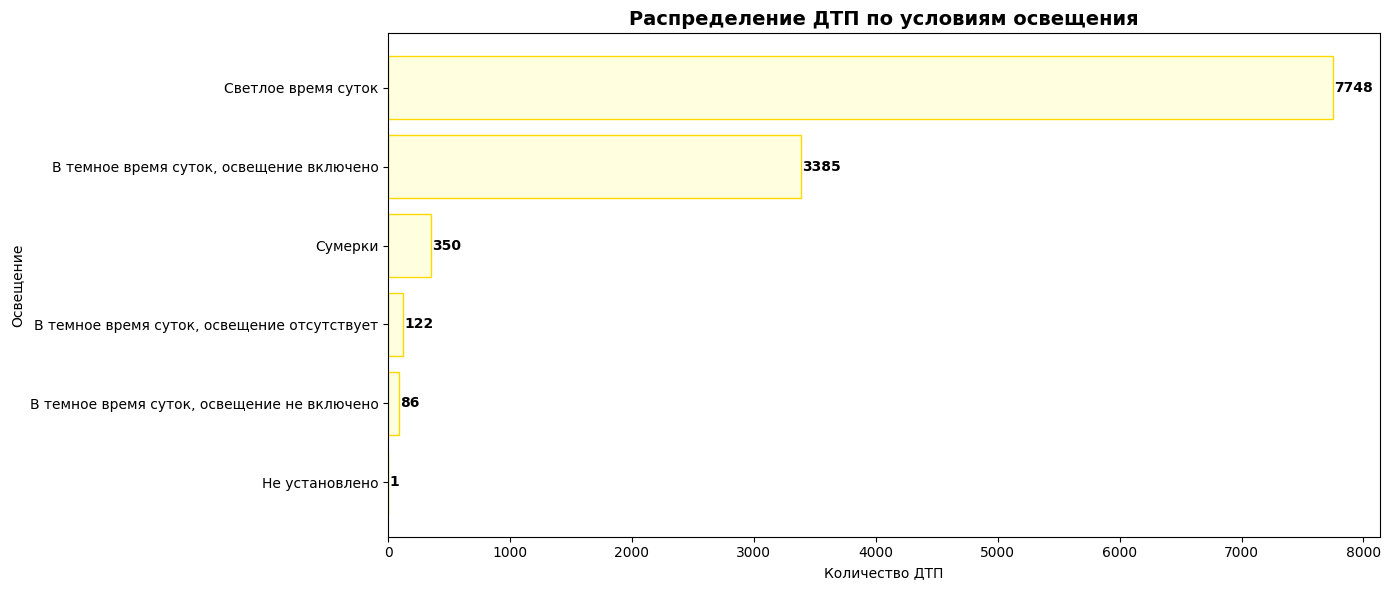

In [113]:
# условия освещения

light_stats = dtp_with_weather.groupby('light_conditions').agg({
    'kart_id': 'count',
    'fatalities': ['sum', 'mean'],
    'injured': ['sum', 'mean']
}).round(2)

light_stats.columns = ['dtp_count', 'fatal_sum', 'fatal_mean', 'injured_sum', 'injured_mean']

light_stats['percent'] = (light_stats['dtp_count'] / len(dtp_with_weather) * 100).round(2)
light_stats['fatal_per_100'] = (light_stats['fatal_sum'] / light_stats['dtp_count'] * 100).round(2)
light_stats['injured_per_100'] = (light_stats['injured_sum'] / light_stats['dtp_count'] * 100).round(2)

light_sorted = light_stats.sort_values('dtp_count', ascending=False)

print("\nРаспределение ДТП по условиям освещения:")
print(f"{'Освещение':<45} {'ДТП':>6} {'%':>6} {'Погибшие/100':>12} {'Раненые/100':>12}")

for light, row in light_sorted.iterrows():
    print(f"{light[:45]:<45} {int(row['dtp_count']):>6} {row['percent']:>6} {row['fatal_per_100']:>11} {row['injured_per_100']:>12}")
print()

plt.figure(figsize=(14, 6))

plot_data = light_sorted.sort_values('dtp_count', ascending=True)

bars = plt.barh(plot_data.index, plot_data['dtp_count'], color='lightyellow', edgecolor='gold')
plt.title('Распределение ДТП по условиям освещения', fontsize=14, fontweight='bold')
plt.xlabel('Количество ДТП')
plt.ylabel('Освещение')

for bar, count in zip(bars, plot_data['dtp_count']):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
             f'{int(count)}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()
print()

Созданные переменные для корреляции:
['light_danger_level', 'is_dark', 'light_problems', 'fatalities', 'injured']

Статистика по новым переменным:
ДТП в темное время суток: 3593 (30.7%)
ДТП с проблемами освещения: 208 (1.8%)
Коэффициенты корреляции Пирсона:
                    light_danger_level  is_dark  light_problems  fatalities  \
light_danger_level               1.000    0.960           0.398       0.102   
is_dark                          0.960    1.000           0.202       0.089   
light_problems                   0.398    0.202           1.000       0.088   
fatalities                       0.102    0.089           0.088       1.000   
injured                          0.032    0.033          -0.000      -0.142   

                    injured  
light_danger_level    0.032  
is_dark               0.033  
light_problems       -0.000  
fatalities           -0.142  
injured               1.000  



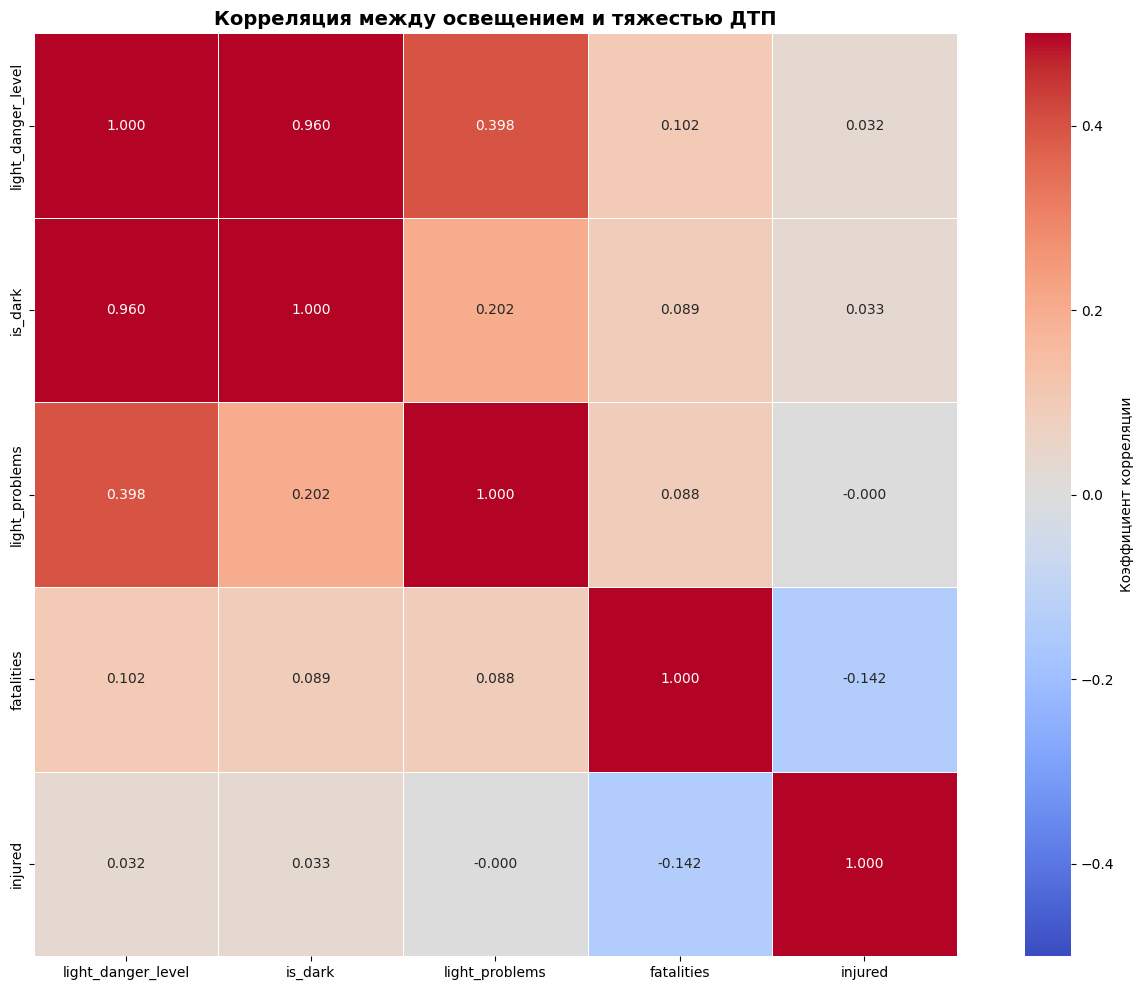

In [125]:
# корреляционная матрица: освещенность и ДТП

dtp_light = dtp_with_weather.copy()

# создаем числовые переменные для освещения - ранжируем по опасности (на основе fatal_per_100)
light_danger_order = {
    'Светлое время суток': 1,
    'Сумерки': 2,
    'В темное время суток, освещение включено': 3,
    'В темное время суток, освещение не включено': 4,
    'В темное время суток, освещение отсутствует': 5,
    'Не установлено': np.nan
}

dtp_light = pd.get_dummies(dtp_light, columns=['light_conditions'], prefix='light')
dtp_light['light_danger_level'] = dtp_with_weather['light_conditions'].map(light_danger_order)
dtp_light['is_dark'] = dtp_with_weather['light_conditions'].str.contains('темное время суток').astype(int)
dtp_light['light_problems'] = dtp_with_weather['light_conditions'].str.contains('отсутствует|не включено').astype(int)

print("Созданные переменные для корреляции:")
numeric_light_cols = ['light_danger_level', 'is_dark', 'light_problems', 'fatalities', 'injured']
print(numeric_light_cols)
print()

print("Статистика по новым переменным:")
print(f"ДТП в темное время суток: {dtp_light['is_dark'].sum()} ({dtp_light['is_dark'].mean()*100:.1f}%)")
print(f"ДТП с проблемами освещения: {dtp_light['light_problems'].sum()} ({dtp_light['light_problems'].mean()*100:.1f}%)")


light_corr_matrix = dtp_light[numeric_light_cols].corr(method='pearson').round(3)

print("Коэффициенты корреляции Пирсона:")
print(light_corr_matrix)
print()

plt.figure(figsize=(14, 10))
sns.heatmap(light_corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-0.5, vmax=0.5,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Корреляция между освещением и тяжестью ДТП', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Топ-10 недостатков дороги:

1. Отсутствие, плохая различимость горизонтальной разметки проезжей части: 3266 (27.93% от всех ДТП)
2. Недостатки зимнего содержания: 704 (6.02% от всех ДТП)
3. Отсутствие дорожных знаков в необходимых местах: 491 (4.20% от всех ДТП)
4. Дефекты покрытия: 373 (3.19% от всех ДТП)
5. Неправильное применение, плохая видимость дорожных знаков: 264 (2.26% от всех ДТП)
6. Отсутствие тротуаров (пешеходных дорожек): 138 (1.18% от всех ДТП)
7. Отсутствие пешеходных ограждений в необходимых местах: 76 (0.65% от всех ДТП)
8. Неудовлетворительное состояние обочин: 66 (0.56% от всех ДТП)
9. Неровное покрытие: 55 (0.47% от всех ДТП)
10. Иные недостатки: 35 (0.30% от всех ДТП)

Всего ДТП: 11692
ДТП без недостатков: 0 (0.0%)
ДТП с неустановленным статусом: 6030 (51.6%)
ДТП с подтвержденными недостатками: 5662 (48.4%)

Погибшие на 100 ДТП (исключая 'Не установлены'):
  С недостатками: 3.76
  Без недостатков: 0.00



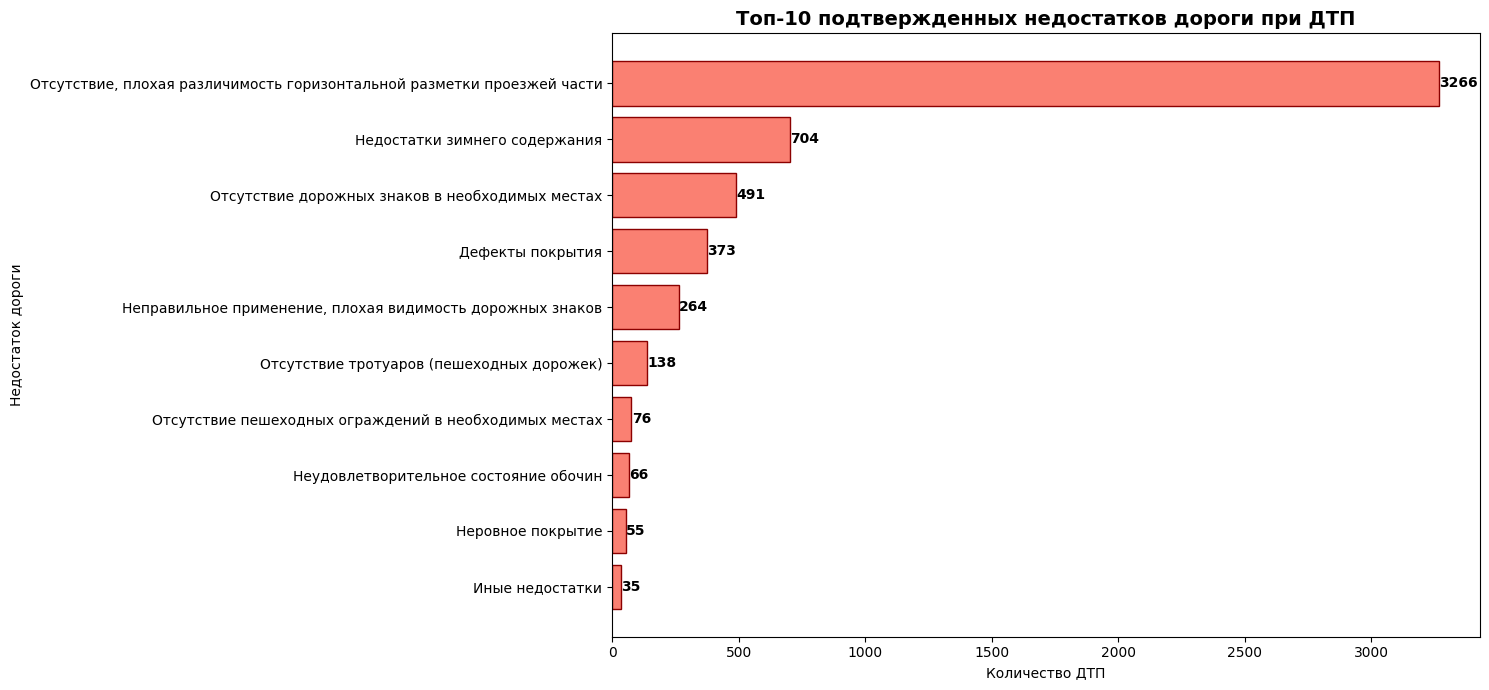

In [ ]:
# недостатки дороги

def get_deficiency(deficiencies):
    if not isinstance(deficiencies, list) or len(deficiencies) == 0:
        return 'Нет недостатков'
    return deficiencies[0]

dtp_with_weather['deficiency'] = dtp_with_weather['road_deficiencies'].apply(get_deficiency)

dtp_with_weather['has_real_defect'] = dtp_with_weather['deficiency'].apply(
    lambda x: x not in ['Нет недостатков', 'Не установлены']
)
real_deficiencies = dtp_with_weather[dtp_with_weather['has_real_defect']]['deficiency'].value_counts().head(10)

print("Топ-10 недостатков дороги:\n")
for i, (deficiency, count) in enumerate(real_deficiencies.items(), 1):
    print(f"{i}. {deficiency}: {count} ({count/len(dtp_with_weather)*100:.2f}% от всех ДТП)")
print()

total_dtp = len(dtp_with_weather)
no_defect = (dtp_with_weather['deficiency'] == 'Нет недостатков').sum()
not_established = (dtp_with_weather['deficiency'] == 'Не установлены').sum()
has_defect = total_dtp - no_defect - not_established

print(f"Всего ДТП: {total_dtp}")
print(f"ДТП без недостатков: {no_defect} ({no_defect/total_dtp*100:.1f}%)")
print(f"ДТП с неустановленным статусом: {not_established} ({not_established/total_dtp*100:.1f}%)")
print(f"ДТП с подтвержденными недостатками: {has_defect} ({has_defect/total_dtp*100:.1f}%)")
print()

dtp_clean = dtp_with_weather[dtp_with_weather['deficiency'] != 'Не установлены'].copy()
dtp_clean['has_defect_flag'] = dtp_clean['deficiency'] != 'Нет недостатков'

defect_fatal = dtp_clean.groupby('has_defect_flag')['fatalities'].mean() * 100
print("Погибшие на 100 ДТП (исключая 'Не установлены'):")
print(f"  С недостатками: {defect_fatal.get(True, 0):.2f}")
print(f"  Без недостатков: {defect_fatal.get(False, 0):.2f}")
print()

# Горизонтальная диаграмма топ-10 реальных недостатков
if len(real_deficiencies) > 0:
    plt.figure(figsize=(15, 7))
    real_deficiencies_sorted = real_deficiencies.sort_values(ascending=True)
    bars = plt.barh(real_deficiencies_sorted.index, real_deficiencies_sorted.values, 
                    color='salmon', edgecolor='darkred')
    plt.title('Топ-10 подтвержденных недостатков дороги при ДТП', fontsize=14, fontweight='bold')
    plt.xlabel('Количество ДТП')
    plt.ylabel('Недостаток дороги')

    for bar, val in zip(bars, real_deficiencies_sorted.values):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                 f'{val}', ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных о подтвержденных недостатках дороги")

In [ ]:
# городская специфика

cities = dtp_with_weather['district'].unique()

for city in cities:
    print(f"\n{city}\n")
    city_data = dtp_with_weather[dtp_with_weather['district'] == city]
    print(f"Всего ДТП: {len(city_data)}")
    
    # Топ-3 погоды
    top_weather = city_data['weather_main'].value_counts().head(3)
    print("Топ-3 погоды при ДТП:")
    for weather, count in top_weather.items():
        print(f"  {weather}: {count} ({count/len(city_data)*100:.1f}%)")
    
    # Осадки
    rain_pct = (city_data['rain'] > 0).mean() * 100
    snow_pct = (city_data['snowfall'] > 0).mean() * 100
    print(f"ДТП с дождем: {rain_pct:.1f}%, со снегом: {snow_pct:.1f}%")
    
    # Температура и смертность
    print(f"Средняя температура при ДТП: {city_data['temperature_2m'].mean():.1f}°C")
    fatal_rate = city_data['fatalities'].sum() / len(city_data) * 100
    print(f"Погибших на 100 ДТП: {fatal_rate:.2f}")


Петрозаводск

Всего ДТП: 2685
Топ-3 погоды при ДТП:
  Пасмурно: 1313 (48.9%)
  Ясно: 1085 (40.4%)
  Снегопад: 146 (5.4%)
ДТП с дождем: 15.6%, со снегом: 10.1%
Средняя температура при ДТП: 6.0°C
Погибших на 100 ДТП: 3.99

Тамбов

Всего ДТП: 5256
Топ-3 погоды при ДТП:
  Ясно: 2959 (56.3%)
  Пасмурно: 1847 (35.1%)
  Дождь: 286 (5.4%)
ДТП с дождем: 12.2%, со снегом: 6.0%
Средняя температура при ДТП: 10.0°C
Погибших на 100 ДТП: 2.53

Великий Новгород

Всего ДТП: 3751
Топ-3 погоды при ДТП:
  Ясно: 1778 (47.4%)
  Пасмурно: 1655 (44.1%)
  Дождь: 235 (6.3%)
ДТП с дождем: 17.7%, со снегом: 6.7%
Средняя температура при ДТП: 8.3°C
Погибших на 100 ДТП: 3.07


In [ ]:
# Общие данные
# Самая частая погода
top_weather = weather_dist.index[0] 
top_weather_count = weather_dist.iloc[0]  
top_weather_pct = (top_weather_count / len(dtp_with_weather) * 100).round(1)
print(f"1. Самая частая погода при ДТП: {top_weather} ({top_weather_pct}%)")

# Самая опасная погода
weather_fatal = dtp_with_weather.groupby('weather_main')['fatalities'].mean() * 100
dangerous_weather = weather_fatal.idxmax()
dangerous_rate = weather_fatal.max().round(2)
dangerous_count = weather_dist[dangerous_weather]  
print(f"2. Самая высокая смертность: {dangerous_weather} ({dangerous_rate} на 100 ДТП, {dangerous_count} ДТП)")

# Осадки
fatal_none = dtp_with_weather[dtp_with_weather['precip'] == 'Без осадков']['fatalities'].mean() * 100
fatal_rain = dtp_with_weather[dtp_with_weather['precip'] == 'Дождь']['fatalities'].mean() * 100
fatal_snow = dtp_with_weather[dtp_with_weather['precip'] == 'Снег']['fatalities'].mean() * 100
print(f"3. Смертность по осадкам: без осадков {fatal_none:.2f}, дождь {fatal_rain:.2f}, снег {fatal_snow:.2f} на 100 ДТП")

# Покрытие 
if 'surface_fatal' in locals():
    dangerous_surface = surface_fatal['fatal_per_100'].idxmax()
    dangerous_surface_rate = surface_fatal['fatal_per_100'].max()
    print(f"4. Самое опасное покрытие: {dangerous_surface} ({dangerous_surface_rate:.2f} на 100 ДТП)")

# Освещение 
if 'light_fatal' in locals():
    dangerous_light = light_fatal['fatal_per_100'].idxmax()
    dangerous_light_rate = light_fatal['fatal_per_100'].max()
    print(f"5. Самое опасное освещение: {dangerous_light} ({dangerous_light_rate:.2f} на 100 ДТП)")

# Недостатки дороги
print(f"6. ДТП с подтвержденными недостатками дороги: {has_defect} ({has_defect/len(dtp_with_weather)*100:.1f}% от всех ДТП)")
print(f"   ДТП с неустановленным статусом: {not_established} ({not_established/len(dtp_with_weather)*100:.1f}%)")

1. Самая частая погода при ДТП: Ясно (49.8%)
2. Самая высокая смертность: Дождь (3.34 на 100 ДТП, 658 ДТП)
3. Смертность по осадкам: без осадков 3.13, дождь 3.08, снег 1.92 на 100 ДТП
4. Самое опасное покрытие: Мокрое (3.46 на 100 ДТП)
5. Самое опасное освещение: В темное время суток, освещение отсутствует (18.85 на 100 ДТП)
6. ДТП с подтвержденными недостатками дороги: 5662 (48.4% от всех ДТП)
   ДТП с неустановленным статусом: 6030 (51.6%)


Промежуточные выводы:

Погодные условия и частота ДТП. Половина всех ДТП (49.8%) происходит в ясную погоду – это базовый, наиболее частый фон. Пасмурная погода сопровождает 41.2% ДТП. Осадки (дождь + снег) присутствуют лишь в 8.8% ДТП.

Погода и тяжесть последствий. Самая высокая смертность наблюдается при дожде (3.34 на 100 ДТП), хотя дождь идет лишь в 5.6% случаев. Пасмурная погода и снегопад также показывают повышенную смертность (3.30 и 3.24). Ясная погода – самая "безопасная" (2.78), хотя именно в ней происходит максимум ДТП.

Температурный фактор. Наиболее опасный диапазон – прохладно 0-10°C (4.12 погибших на 100 ДТП) - это переходный период (осень/весна), когда возможны гололед, мокрое покрытие, перепады температур, что подтверждает результаты анализа динамики ДТП по месяцам года. Жара >30°C показывает минимальную смертность (1.35). Корреляционный анализ показал, что нет линейной зависимости между температурой воздуха и количеством погибших или раненых в ДТП. Температура сама по себе не является предиктором тяжести аварии.

Осадки. Дождь и снег встречаются относительно редко (13.9% и 7.1% ДТП соответственно). Снег "безопаснее" дождя (1.92 против 3.08), что подтвержается слабой отрицательной корреляцией (коэффициент -0.014), – вероятно, из-за более низких скоростей движения, лучшей видимости (снег отражает свет в темное время суток). Корреляционный анализ показал, что ни один из показателей осадков (наличие, интенсивность, тип) не имеет значимой линейной корреляции с количеством погибших в ДТП (все коэффициенты близки к нулю).

Комбинированные условия. Лишь 3.3% ДТП происходят при сочетании нескольких погодных факторов. Самая частая комбинация: "Дождь + Пасмурно" (217 ДТП).

Состояние покрытия – важный фактор. Мокрое покрытие – самое опасное (3.46 погибших на 100 ДТП). При этом мокрое покрытие встречается в 26.2% ДТП. Обработанное противогололедными материалами покрытие также опасно (3.19). 

Освещение – важный фактор. Условие "В темное время суток, освещение отсутствует" дает высокую смертность - 18.85 погибших на 100 ДТП - это в 6.8 раз выше, чем в светлое время суток (1.92). При этом таких ДТП всего 1%, но каждое шестое из них смертельно. Этот вывод также подтверждает предварительные выводы о распределении смертельных ДТП в течение суток. Корреляционный анализ показал наличие слабой положительной связи между наличием проблем с освещением и количеством погибших в ДТП (самая сильная связь по сравнению с температурой и осадками), однако, связь между освещенностью и количеством раненых практически отсутствует. 

Общая смертность - 2.81 человек на 100 ДТП, при мокром покрытии - 3.46, при плохом освещении - 18.85. Таким образом, мы можем предполагать, что плохое освещение многократно повышает риск смерти в ДТП. 

Недостатки дорожной инфраструктуры. Почти половина ДТП (48.4%) происходят при подтвержденных недостатках дороги. Главные проблемы: плохая разметка (27.9%), недостатки зимнего содержания (6.0%), отсутствие знаков (4.2%).

Региональные различия. Для анализа были выбраны города - административные центры регионов в европейской части России с сопоставимым населением, но располагающиеся на разных широтах. 

- Тамбов - самый "ясный" город (56.3% ДТП в ясную погоду), самая низкая смертность (2.53), самая высокая средняя температура (10.0°C), самое большое количество ДТП.

- Великий Новгород - промежуточное положение по всем показателям, смертность 3.07 – близко к среднему.

- Петрозаводск - самый "пасмурный" город (48.9% ДТП в пасмурную погоду), самая высокая смертность (3.99 на 100 ДТП), самая низкая средняя температура при ДТП (6.0°C), самое маленькое количество ДТП. 

Гипотеза: климат Петрозаводска может влиять на структуру ДТП и смертность. Для проверки этого предположения, сравним данные по ДТП в Петрозаводске и Тамбове.

*Часть 3. Статистическая проверка гипотез*

ГИПОТЕЗА 1: Смертность в ДТП выше в городе с более суровым климатом

H₀ (нулевая): Нет статистически значимой разницы в доле смертельных ДТП между Петрозаводском и Тамбовом

H₁ (альтернативная): В Петрозаводске доля смертельных ДТП значимо выше, чем в Тамбове

In [126]:
petrozavodsk = dtp_with_weather[dtp_with_weather['district'] == 'Петрозаводск'].copy()
tambov = dtp_with_weather[dtp_with_weather['district'] == 'Тамбов'].copy()

In [135]:
petrozavodsk_fatal = petrozavodsk['fatalities'].sum()
petrozavodsk_nonfatal = len(petrozavodsk) - petrozavodsk_fatal
tambov_fatal = tambov['fatalities'].sum()
tambov_nonfatal = len(tambov) - tambov_fatal

contingency_table = np.array([
    [petrozavodsk_fatal, petrozavodsk_nonfatal],
    [tambov_fatal, tambov_nonfatal]
])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("ГИПОТЕЗА 1: Сравнение доли смертельных ДТП\n")
print(f"Петрозаводск: {petrozavodsk_fatal} смертельных из {len(petrozavodsk)} ({petrozavodsk_fatal/len(petrozavodsk)*100:.2f}%)")
print(f"Тамбов: {tambov_fatal} смертельных из {len(tambov)} ({tambov_fatal/len(tambov)*100:.2f}%)\n")
print(f"χ² = {chi2:.4f}, p-value = {p_value:.6f}\n")

alpha = 0.05
if p_value < alpha:
    print("РЕЗУЛЬТАТ: Отвергаем H₀ - разница статистически значима")
    print(f"  В Петрозаводске действительно выше доля смертельных ДТП")
    
    # Рассчитываем отношение шансов (odds ratio)
    odds_petrozavodsk = petrozavodsk_fatal / petrozavodsk_nonfatal
    odds_tambov = tambov_fatal / tambov_nonfatal
    odds_ratio = odds_petrozavodsk / odds_tambov
    print(f"  Отношение шансов: {odds_ratio:.3f}")
    print(f"  Шанс погибнуть в ДТП в Петрозаводске в {odds_ratio:.2f} раза выше")
else:
    print("РЕЗУЛЬТАТ: Нет оснований отвергнуть H₀")
    print("  Разница в смертности статистически не значима")
print()

ГИПОТЕЗА 1: Сравнение доли смертельных ДТП

Петрозаводск: 107 смертельных из 2685 (3.99%)
Тамбов: 133 смертельных из 5256 (2.53%)

χ² = 12.3389, p-value = 0.000444

РЕЗУЛЬТАТ: Отвергаем H₀ - разница статистически значима
  В Петрозаводске действительно выше доля смертельных ДТП
  Отношение шансов: 1.599
  Шанс погибнуть в ДТП в Петрозаводске в 1.60 раза выше



ГИПОТЕЗА 2: В Петрозаводске выше доля ДТП в сложных погодных условиях

H₀: Доля ДТП при осадках (дождь + снег) одинакова в обоих городах

H₁: В Петрозаводске значимо выше доля ДТП при осадках

In [138]:
petrozavodsk['has_precip'] = (petrozavodsk['rain'] > 0) | (petrozavodsk['snowfall'] > 0)
tambov['has_precip'] = (tambov['rain'] > 0) | (tambov['snowfall'] > 0)

petrozavodsk_precip = petrozavodsk['has_precip'].sum()
petrozavodsk_no_precip = len(petrozavodsk) - petrozavodsk_precip
tambov_precip = tambov['has_precip'].sum()
tambov_no_precip = len(tambov) - tambov_precip

contingency_table = np.array([
    [petrozavodsk_precip, petrozavodsk_no_precip],
    [tambov_precip, tambov_no_precip]
])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("ГИПОТЕЗА 2: Доля ДТП с осадками\n")
print(f"Петрозаводск: {petrozavodsk_precip} ДТП с осадками ({petrozavodsk_precip/len(petrozavodsk)*100:.1f}%)")
print(f"Тамбов: {tambov_precip} ДТП с осадками ({tambov_precip/len(tambov)*100:.1f}%)\n")
print(f"χ² = {chi2:.4f}, p-value = {p_value}\n")

if p_value < alpha:
    print("РЕЗУЛЬТАТ: Отвергаем H₀ — разница статистически значима")
    print("  В Петрозаводске действительно чаще ДТП в осадки")
    
    # Детализация по типам осадков
    petrozavodsk_rain = (petrozavodsk['rain'] > 0).sum()
    petrozavodsk_snow = (petrozavodsk['snowfall'] > 0).sum()
    tambov_rain = (tambov['rain'] > 0).sum()
    tambov_snow = (tambov['snowfall'] > 0).sum()
    
    print(f"  Дождь: Петрозаводск {petrozavodsk_rain/len(petrozavodsk)*100:.1f}%, Тамбов {tambov_rain/len(tambov)*100:.1f}%")
    print(f"  Снег: Петрозаводск {petrozavodsk_snow/len(petrozavodsk)*100:.1f}%, Тамбов {tambov_snow/len(tambov)*100:.1f}%")
else:
    print("РЕЗУЛЬТАТ: Нет оснований отвергнуть H₀")
print()

ГИПОТЕЗА 2: Доля ДТП с осадками

Петрозаводск: 662 ДТП с осадками (24.7%)
Тамбов: 922 ДТП с осадками (17.5%)

χ² = 55.8739, p-value = 7.727327225333137e-14

РЕЗУЛЬТАТ: Отвергаем H₀ — разница статистически значима
  В Петрозаводске действительно чаще ДТП в осадки
  Дождь: Петрозаводск 15.6%, Тамбов 12.2%
  Снег: Петрозаводск 10.1%, Тамбов 6.0%



ГИПОТЕЗА 3: Тяжесть ДТП при одинаковых погодных условиях различается между городами

H₀: Смертность при дожде одинакова в Петрозаводске и Тамбове

H₁: Смертность при дожде в Петрозаводске выше, чем в Тамбове

In [148]:
petrozavodsk_rain = petrozavodsk[petrozavodsk['rain'] > 0]
tambov_rain = tambov[tambov['rain'] > 0]

print("ГИПОТЕЗА 3: Смертность при дожде\n")

if len(petrozavodsk_rain) > 10 and len(tambov_rain) > 10:
    print(f"Петрозаводск при дожде: {len(petrozavodsk_rain)} ДТП, {petrozavodsk_rain['fatalities'].sum()} погибших")
    print(f"  Смертность: {petrozavodsk_rain['fatalities'].mean()*100:.2f} на 100 ДТП")
    print(f"Тамбов при дожде: {len(tambov_rain)} ДТП, {tambov_rain['fatalities'].sum()} погибших")
    print(f"  Смертность: {tambov_rain['fatalities'].mean()*100:.2f} на 100 ДТП")
    
    # U-тест Манна-Уитни (непараметрический, для распределений не похожих на нормальное)
    stat, p_value = mannwhitneyu(petrozavodsk_rain['fatalities'], tambov_rain['fatalities'], 
                                  alternative='two-sided')
    
    print(f"\nU-статистика = {stat:.3f}, p-value = {p_value:.6f}\n")
    
    if p_value < alpha:
        print("РЕЗУЛЬТАТ: Отвергаем H₀ - разница статистически значима")
        
        # Проверяем направление
        if petrozavodsk_rain['fatalities'].mean() > tambov_rain['fatalities'].mean():
            print("  В Петрозаводске дожди опаснее (выше смертность)")
        else:
            print("  В Тамбове дожди опаснее (выше смертность)")
    else:
        print("РЕЗУЛЬТАТ: Нет оснований отвергнуть H₀")
        print("  При одинаковых погодных условиях (дождь) смертность не различается")
else:
    print("Недостаточно данных для анализа (менее 10 ДТП с дождем в одном из городов)")
print()

ГИПОТЕЗА 3: Смертность при дожде

Петрозаводск при дожде: 420 ДТП, 19 погибших
  Смертность: 4.52 на 100 ДТП
Тамбов при дожде: 643 ДТП, 13 погибших
  Смертность: 2.02 на 100 ДТП

U-статистика = 138408.500, p-value = 0.019676

РЕЗУЛЬТАТ: Отвергаем H₀ - разница статистически значима
  В Петрозаводске дожди опаснее (выше смертность)



ГИПОТЕЗА 4: В Петрозаводске выше доля ДТП со сложными условиями покрытия

H₀: Доля ДТП со сложным покрытием (мокрое, снег, гололед) одинакова в обоих городах

H₁: В Петрозаводске значимо выше доля ДТП со сложным покрытием

In [147]:
difficult_surfaces = ['Мокрое', 'Заснеженное', 'Гололедица', 'Со снежным накатом']

petrozavodsk_difficult = petrozavodsk[petrozavodsk['road_surface'].isin(difficult_surfaces)].shape[0]
petrozavodsk_normal = len(petrozavodsk) - petrozavodsk_difficult
tambov_difficult = tambov[tambov['road_surface'].isin(difficult_surfaces)].shape[0]
tambov_normal = len(tambov) - tambov_difficult

contingency_table = np.array([
    [petrozavodsk_difficult, petrozavodsk_normal],
    [tambov_difficult, tambov_normal]
])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("ГИПОТЕЗА 4: Доля ДТП со сложными условиями покрытия\n")
print(f"Петрозаводск: {petrozavodsk_difficult} ДТП со сложным покрытием ({petrozavodsk_difficult/len(petrozavodsk)*100:.1f}%)")
print(f"Тамбов: {tambov_difficult} ДТП со сложным покрытием ({tambov_difficult/len(tambov)*100:.1f}%)\n")
print(f"χ² = {chi2:.4f}, p-value = {p_value}\n")

if p_value < alpha:
    print("РЕЗУЛЬТАТ: Отвергаем H₀ - разница статистически значима")
    print("  В Петрозаводске действительно чаще сложные условия на дороге")
    
    # Детализация по типам покрытия
    print("\nДетализация по типам покрытия (% от всех ДТП в городе):")
    for surface in difficult_surfaces:
        petrozavodsk_pct = (petrozavodsk['road_surface'] == surface).sum() / len(petrozavodsk) * 100
        tambov_pct = (tambov['road_surface'] == surface).sum() / len(tambov) * 100
        print(f"  {surface}: Петрозаводск {petrozavodsk_pct:.1f}%, Тамбов {tambov_pct:.1f}%")
else:
    print("РЕЗУЛЬТАТ: Нет оснований отвергнуть H₀")
print()

ГИПОТЕЗА 4: Доля ДТП со сложными условиями покрытия

Петрозаводск: 871 ДТП со сложным покрытием (32.4%)
Тамбов: 1195 ДТП со сложным покрытием (22.7%)

χ² = 86.4324, p-value = 1.4459660507803243e-20

РЕЗУЛЬТАТ: Отвергаем H₀ - разница статистически значима
  В Петрозаводске действительно чаще сложные условия на дороге

Детализация по типам покрытия (% от всех ДТП в городе):
  Мокрое: Петрозаводск 27.9%, Тамбов 20.7%
  Заснеженное: Петрозаводск 2.3%, Тамбов 1.5%
  Гололедица: Петрозаводск 0.9%, Тамбов 0.4%
  Со снежным накатом: Петрозаводск 1.3%, Тамбов 0.1%



ГИПОТЕЗА 5: Доля ДТП в темное время суток (зафиксированное условие ДТП) различается между городами

H₀: Нет разницы в доле ДТП, происходящих в темное время суток (по данным освещения)

H₁: Доля ДТП в темное время суток различается между Петрозаводском и Тамбовом


In [152]:
# распределение по фактическим условиям освещения
print("Петрозаводск - распределение по освещению:")
print(petrozavodsk['light_conditions'].value_counts(normalize=True).head())
print("\nТамбов - распределение по освещению:")
print(tambov['light_conditions'].value_counts(normalize=True).head())

Петрозаводск - распределение по освещению:
light_conditions
Светлое время суток                            0.649907
В темное время суток, освещение включено       0.314711
Сумерки                                        0.016760
В темное время суток, освещение отсутствует    0.014525
В темное время суток, освещение не включено    0.004097
Name: proportion, dtype: float64

Тамбов - распределение по освещению:
light_conditions
Светлое время суток                            0.674848
В темное время суток, освещение включено       0.280822
Сумерки                                        0.025304
В темное время суток, освещение не включено    0.011606
В темное время суток, освещение отсутствует    0.007230
Name: proportion, dtype: float64


In [158]:
# Словарь для маппинга
dark_mapping = {
    'В темное время суток, освещение включено': 1,
    'В темное время суток, освещение отсутствует': 1,
    'В темное время суток, освещение не включено': 1,
    'Светлое время суток': 0,
    'Сумерки': np.nan
}

petrozavodsk['is_dark'] = petrozavodsk['light_conditions'].map(dark_mapping)
tambov['is_dark'] = tambov['light_conditions'].map(dark_mapping)

petrozavodsk_clean = petrozavodsk['is_dark'].dropna()
tambov_clean = tambov['is_dark'].dropna()

petrozavodsk_dark = petrozavodsk_clean.sum()  
petrozavodsk_light = len(petrozavodsk_clean) - petrozavodsk_dark  

tambov_dark = tambov_clean.sum()
tambov_light = len(tambov_clean) - tambov_dark

print("ГИПОТЕЗА 5: Сравнение доли ДТП в темное время суток")
print(f"\nПетрозаводск:")
print(f"  • Всего ДТП (без сумерек): {len(petrozavodsk_clean)}")
print(f"  • Темное время: {petrozavodsk_dark} ({petrozavodsk_dark/len(petrozavodsk_clean)*100:.2f}%)")
print(f"  • Светлое время: {petrozavodsk_light} ({petrozavodsk_light/len(petrozavodsk_clean)*100:.2f}%)")

print(f"\nТамбов:")
print(f"  • Всего ДТП (без сумерек): {len(tambov_clean)}")
print(f"  • Темное время: {tambov_dark} ({tambov_dark/len(tambov_clean)*100:.2f}%)")
print(f"  • Светлое время: {tambov_light} ({tambov_light/len(tambov_clean)*100:.2f}%)")

contingency_table = np.array([
    [petrozavodsk_dark, petrozavodsk_light],
    [tambov_dark, tambov_light]
])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nχ² = {chi2:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"Степени свободы = {dof}\n")

if p_value < 0.05:
    print("РЕЗУЛЬТАТ: Отвергаем H₀ - разница статистически значима")
    if petrozavodsk_dark/len(petrozavodsk_clean) > tambov_dark/len(tambov_clean):
        print(f"  В Петрозаводске выше доля ДТП в темное время (33.33% vs 29.96%)")
    else:
        print(f"  В Тамбове выше доля ДТП в темное время ({tambov_dark/len(tambov_clean)*100:.2f}% vs {petrozavodsk_dark/len(petrozavodsk_clean)*100:.2f}%)")
else:
    print("РЕЗУЛЬТАТ: Нет оснований отвергнуть H₀")
    print("  Доля ДТП в темное время суток не различается статистически значимо")

ГИПОТЕЗА 5: Сравнение доли ДТП в темное время суток

Петрозаводск:
  • Всего ДТП (без сумерек): 2640
  • Темное время: 895.0 (33.90%)
  • Светлое время: 1745.0 (66.10%)

Тамбов:
  • Всего ДТП (без сумерек): 5122
  • Темное время: 1575.0 (30.75%)
  • Светлое время: 3547.0 (69.25%)

χ² = 7.8320
p-value = 0.005133
Степени свободы = 1

РЕЗУЛЬТАТ: Отвергаем H₀ - разница статистически значима
  В Петрозаводске выше доля ДТП в темное время (33.33% vs 29.96%)


Промежуточные выводы:

Статистический анализ подтвердил, что различия между Петрозаводском и Тамбовом неслучайны. В Петрозаводске значимо выше доля смертельных ДТП, чаще встречаются осадки и сложные дорожные условия, а сами дожди в этом городе являются более опасными. Доля ДТП в темное время суток также выше в Петрозаводске. Это позволяет предположить, что климатические и географические особенности (северное расположение, более сложные погодные условия) вносят существенный вклад в статистику аварийности и ее тяжесть.